In [1]:
# ============================================================
# 模擬資料比較實驗框架 v3（已修正版）
#
# 核心理念：直接比較四個方法預測非線性時間序列的不確定性估計能力
# 不再經過卡爾曼濾波 + ARIMA，排除前處理的干擾
#
# 五種方法（與論文定義一致）：
#   M1: DistPred-ANN              (CRPS Loss  + 100 bins → 後處理取分位數)
#   M2: DistPred-Minusformer      (CRPS Loss  + 100 bins → 後處理取分位數)
#   M3: Quantile-ANN (Monotone)   (Pinball Loss + Softplus 單調約束 → 直接輸出 3 分位數)
#   M4: Quantile-Minusformer (Monotone) (Pinball Loss + Softplus 單調約束 → 直接輸出 3 分位數)
#   M5: Sort Bootstrap + ANN      (MSE Loss + 有放回排序重抽樣 100 次 → 分位數取區間)
#
# 三種 DGP（各自獨立實驗，測試方法的穩健性）：
#   DGP1: 低持續性 GARCH(1,1)  (α=0.10, β=0.60)
#   DGP2: 高持續性 GARCH(1,1)  (α=0.10, β=0.85)
#   DGP3: 高反應性 GARCH(1,1)  (α=0.25, β=0.65)
#
# ── 修正說明 ──────────────────────────────────────────────────
# [Fix 1] M3/M4 骨幹網路對調：
#         原 M3=QuantileMinusformer, M4=QuantileANN_Monotone
#         修正為 M3=QuantileANN_Monotone, M4=QuantileMinusformer
#         以符合論文定義（M3=ANN, M4=Minusformer）
#
# [Fix 2] QuantileMinusformer (M4) 補上 Softplus 單調約束：
#         原版直接輸出 3 個分位數，未保證 q_low ≤ q_mid ≤ q_high
#         修正為與 M3 相同的結構單調設計
#
# [Fix 3] DistPredANN / QuantileANN_Monotone 的 register_buffer 移除：
#         標準化參數改為 forward 內的局部變數，避免語義混淆
#
# [Fix 4] DistPredMinusformer 的 inverse_transform 維度修正：
#         確保 scaler 的 std/mean 正確還原至預測輸出
#
# ── v3 核心設計 ──────────────────────────────────────────────────
#   對同一個 DGP 重複 n_seeds=100 次（每次不同 seed，產生不同資料）。
#   每次對後 20%（240 個測試點）各自預測區間。
#   最終每個測試位置（pos 0~239）都累積了 100 個「是否被涵蓋」的 0/1 結果，
#   可以計算：
#     - 每個位置的涵蓋率 coverage_rate[pos] = 被涵蓋次數 / 100
#     - 整體 PICP = mean(coverage_rate)，目標 ≈ 95%
#     - 位置層級的涵蓋率折線圖，可看出哪些位置系統性偏低/偏高
# ============================================================

## 1. 導入庫

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
from scipy import stats
from collections import defaultdict

print("所有庫導入成功!")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")

所有庫導入成功!
PyTorch 版本: 2.4.0+cu121
CUDA 可用: True


## 2. 實驗配置

In [3]:
class ExperimentConfig:
    # ── 資料參數 ─────────────────────────────────────────────────────
    n_total     = 1200    # 總資料長度
    train_prob  = 0.8     # 訓練比例

    # ── 重複實驗設定 ─────────────────────────────────────────────────
    n_seeds = 100          # 重複 100 次，每個測試位置累積 100 個涵蓋結果
    seeds   = list(range(2020, 2020 + n_seeds))

    # ── 模型共用參數 ─────────────────────────────────────────────────
    seq_len       = 30
    pred_len      = 1
    batch_size    = 32
    learning_rate = 0.001
    train_epochs  = 50
    patience      = 5
    quantiles     = [0.025, 0.5, 0.975]
    n_quantiles   = 3

    # ── ANN 系列參數 ──────────────────────────────────────────────────
    hidden_dims  = [128, 256, 128]
    dropout_ann  = 0.2
    bins         = 100

    # ── Minusformer 系列參數 ──────────────────────────────────────────
    label_len    = 15
    d_model      = 128
    d_ff         = 128
    e_layers     = 2
    dropout_tf   = 0.1
    gate         = 1

    # ── M5: Sort Bootstrap + ANN 參數 ────────────────────────────────
    bootstrap_iters  = 100   # bootstrap 重抽樣次數
    bootstrap_window = 30    # 與 seq_len 一致

    # ── 設備 & 輸出 ───────────────────────────────────────────────────
    device     = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    output_dir = './sim_results_v3'
    save_plots = True

cfg = ExperimentConfig()
os.makedirs(cfg.output_dir, exist_ok=True)

# 測試集長度（固定，所有 seed 相同）
N_TEST = cfg.n_total - int(cfg.train_prob * cfg.n_total)   # = 240

print("=" * 60)
print(f"設備: {cfg.device}  |  n_seeds: {cfg.n_seeds}  |  n_total: {cfg.n_total}")
print(f"每個測試位置將累積 {cfg.n_seeds} 次涵蓋結果 (N_TEST={N_TEST})")
print("五種方法：M1 DistPred-ANN, M2 DistPred-Minusformer, M3 Quantile-ANN,")
print("         M4 Quantile-Minusformer, M5 Sort Bootstrap + ANN")
print("=" * 60)

設備: cuda:0  |  n_seeds: 100  |  n_total: 1200
每個測試位置將累積 100 次涵蓋結果 (N_TEST=240)
五種方法：M1 DistPred-ANN, M2 DistPred-Minusformer, M3 Quantile-ANN,
         M4 Quantile-Minusformer, M5 Sort Bootstrap + ANN


## 3. 三種 GARCH(1,1) DGP 定義

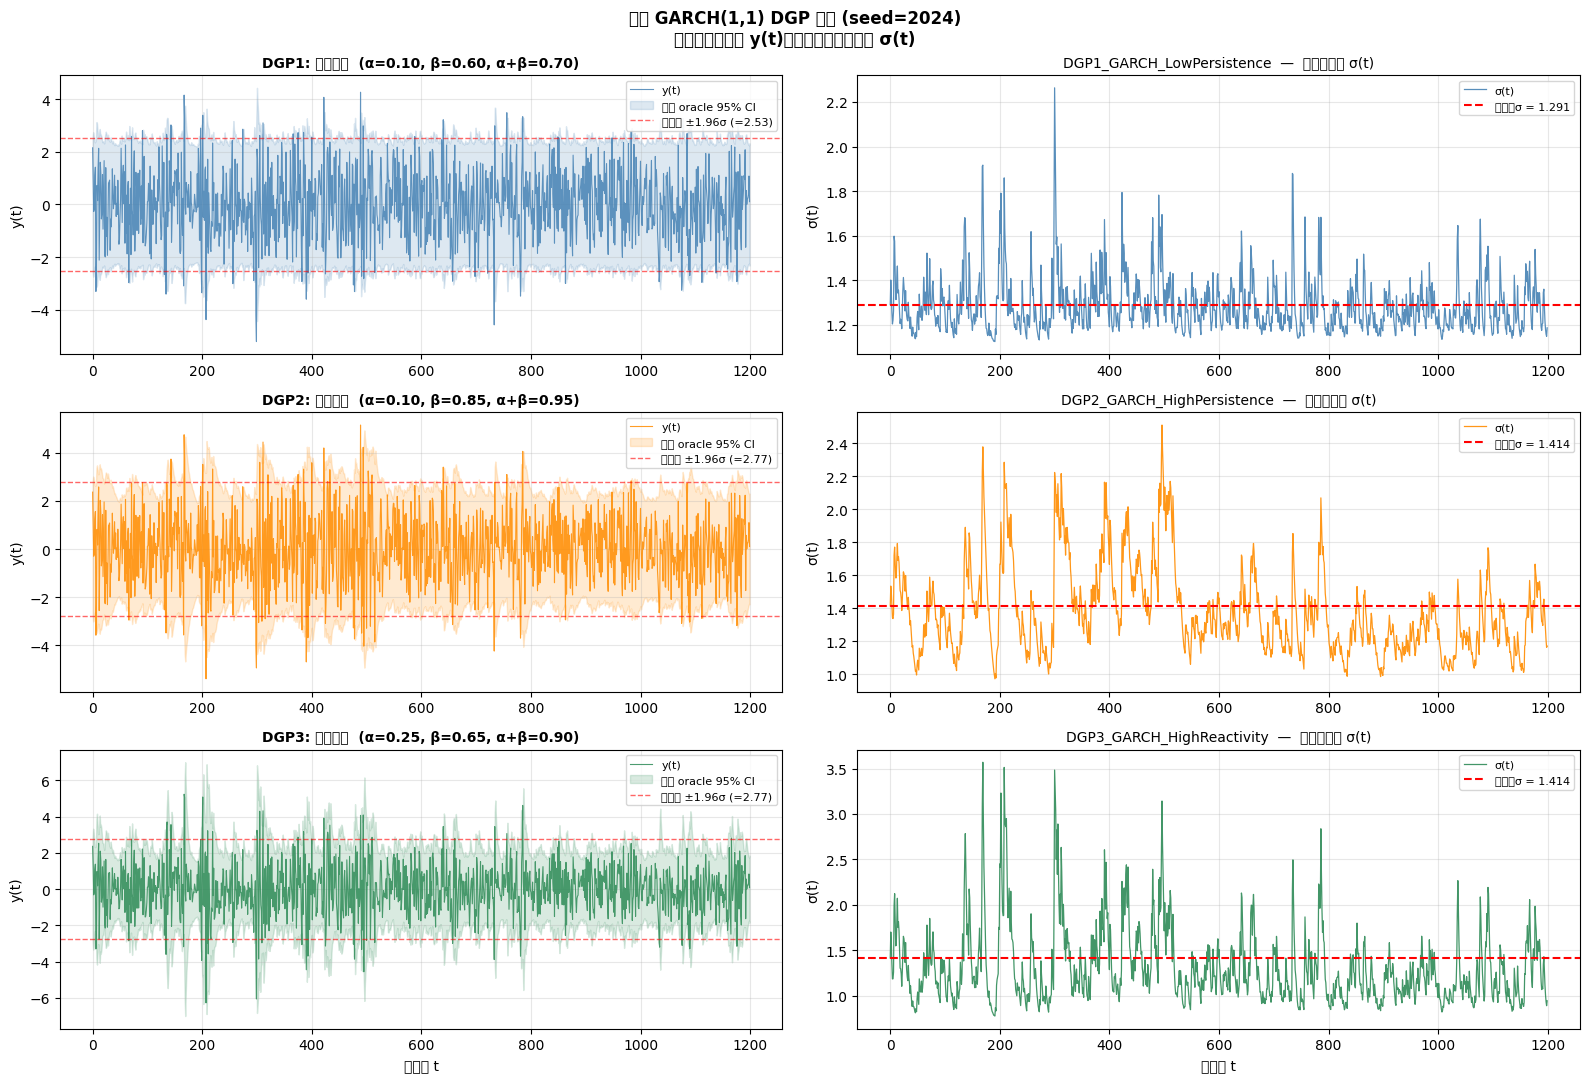


三種 GARCH(1,1) DGP 統計（seed=2024）:
  DGP                                     α+β      無條件σ       y均值      y標準差      oracle CI寬(平均)
  DGP1_GARCH_LowPersistence              0.70    1.2910   -0.0080    1.2962              5.0441
  DGP2_GARCH_HighPersistence             0.95    1.4142   -0.0071    1.4012              5.4161
  DGP3_GARCH_HighReactivity              0.90    1.4142   -0.0049    1.3630              5.1555

✅ GARCH DGP 定義完成


In [4]:
def simulate_garch11(n, omega, alpha, beta, mu=0.0, seed=0):
    """
    模擬 GARCH(1,1) + Gaussian 創新項

    模型：
        y(t) = mu + eps(t)
        eps(t) = sigma(t) * z(t),   z(t) ~ N(0,1)
        sigma²(t) = omega + alpha * eps²(t-1) + beta * sigma²(t-1)

    穩定條件：alpha + beta < 1
    無條件方差：sigma²_unconditional = omega / (1 - alpha - beta)
    """
    assert alpha + beta < 1, f"不穩定：alpha+beta={alpha+beta:.3f} >= 1"
    assert omega > 0 and alpha >= 0 and beta >= 0

    rng = np.random.RandomState(seed)
    z = rng.standard_normal(n)

    sigma2 = np.zeros(n)
    eps    = np.zeros(n)
    y      = np.zeros(n)

    sigma2_unconditional = omega / (1.0 - alpha - beta)
    sigma2[0] = sigma2_unconditional
    eps[0]    = np.sqrt(sigma2[0]) * z[0]
    y[0]      = mu + eps[0]

    for t in range(1, n):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
        eps[t]    = np.sqrt(sigma2[t]) * z[t]
        y[t]      = mu + eps[t]

    sigma_t = np.sqrt(sigma2)
    return y, sigma_t


def dgp1_garch_low_persistence(n, seed=0):
    """DGP1: 低持續性 GARCH(1,1)  α=0.10, β=0.60 → α+β=0.70"""
    return simulate_garch11(n, omega=0.5, alpha=0.10, beta=0.60, seed=seed)


def dgp2_garch_high_persistence(n, seed=0):
    """DGP2: 高持續性 GARCH(1,1)  α=0.10, β=0.85 → α+β=0.95"""
    return simulate_garch11(n, omega=0.1, alpha=0.10, beta=0.85, seed=seed)


def dgp3_garch_high_reactivity(n, seed=0):
    """DGP3: 高反應性 GARCH(1,1)  α=0.25, β=0.65 → α+β=0.90"""
    return simulate_garch11(n, omega=0.2, alpha=0.25, beta=0.65, seed=seed)


DGP_REGISTRY = {
    'DGP1_GARCH_LowPersistence'  : dgp1_garch_low_persistence,
    'DGP2_GARCH_HighPersistence' : dgp2_garch_high_persistence,
    'DGP3_GARCH_HighReactivity'  : dgp3_garch_high_reactivity,
}

DGP_PARAMS = {
    'DGP1_GARCH_LowPersistence'  : dict(omega=0.5,  alpha=0.10, beta=0.60),
    'DGP2_GARCH_HighPersistence' : dict(omega=0.1,  alpha=0.10, beta=0.85),
    'DGP3_GARCH_HighReactivity'  : dict(omega=0.2,  alpha=0.25, beta=0.65),
}

# ── 示範視覺化（seed=2024）─────────────────────────────────────────────
z_95 = stats.norm.ppf(0.975)

fig, axes = plt.subplots(3, 2, figsize=(16, 11))
dgp_list   = list(DGP_REGISTRY.items())
colors     = ['steelblue', 'darkorange', 'seagreen']
subtitles  = [
    'DGP1: 低持續性  (α=0.10, β=0.60, α+β=0.70)',
    'DGP2: 高持續性  (α=0.10, β=0.85, α+β=0.95)',
    'DGP3: 高反應性  (α=0.25, β=0.65, α+β=0.90)',
]

for row, (dgp_name, dgp_func) in enumerate(dgp_list):
    y_demo, sigma_demo = dgp_func(cfg.n_total, seed=2024)
    p = DGP_PARAMS[dgp_name]
    sigma_unc = np.sqrt(p['omega'] / (1 - p['alpha'] - p['beta']))

    ax_y = axes[row, 0]
    ax_y.plot(y_demo, lw=0.8, color=colors[row], alpha=0.85, label='y(t)')
    ax_y.fill_between(range(cfg.n_total),
                      -z_95 * sigma_demo, z_95 * sigma_demo,
                      alpha=0.18, color=colors[row], label='理論 oracle 95% CI')
    ax_y.axhline( z_95 * sigma_unc, color='red',  lw=1, ls='--', alpha=0.6,
                  label=f'無條件 ±1.96σ (={z_95*sigma_unc:.2f})')
    ax_y.axhline(-z_95 * sigma_unc, color='red',  lw=1, ls='--', alpha=0.6)
    ax_y.set_title(subtitles[row], fontsize=10, fontweight='bold')
    ax_y.set_ylabel('y(t)', fontsize=10)
    ax_y.legend(fontsize=8, loc='upper right')
    ax_y.grid(True, alpha=0.3)

    ax_s = axes[row, 1]
    ax_s.plot(sigma_demo, lw=0.9, color=colors[row], alpha=0.9, label='σ(t)')
    ax_s.axhline(sigma_unc, color='red', lw=1.5, ls='--',
                 label=f'無條件σ = {sigma_unc:.3f}')
    ax_s.set_title(f'{dgp_name}  —  條件標準差 σ(t)', fontsize=10)
    ax_s.set_ylabel('σ(t)', fontsize=10)
    ax_s.legend(fontsize=8)
    ax_s.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('時間步 t', fontsize=10)

fig.suptitle('三種 GARCH(1,1) DGP 示範 (seed=2024)\n'
             '左欄：觀測序列 y(t)；右欄：條件標準差 σ(t)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
if cfg.save_plots:
    plt.savefig(f'{cfg.output_dir}/dgp_garch_overview.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n三種 GARCH(1,1) DGP 統計（seed=2024）:")
print(f"  {'DGP':<35}  {'α+β':>6}  {'無條件σ':>8}  {'y均值':>8}  {'y標準差':>8}  {'oracle CI寬(平均)':>18}")
for dgp_name, dgp_func in dgp_list:
    p = DGP_PARAMS[dgp_name]
    y_d, sig_d = dgp_func(cfg.n_total, seed=2024)
    sigma_unc = np.sqrt(p['omega'] / (1 - p['alpha'] - p['beta']))
    oracle_width = np.mean(2 * z_95 * sig_d)
    print(f"  {dgp_name:<35}  {p['alpha']+p['beta']:>6.2f}  "
          f"{sigma_unc:>8.4f}  {y_d.mean():>8.4f}  {y_d.std():>8.4f}  "
          f"{oracle_width:>18.4f}")

print("\n✅ GARCH DGP 定義完成")

## 4. 工具函數

In [5]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def compute_PICP(y_true, lower, upper):
    """整體 PICP（%）"""
    return np.mean((y_true >= lower) & (y_true <= upper)) * 100

def compute_coverage_per_position(covered_matrix):
    """
    covered_matrix: shape [n_seeds, N_TEST]，元素為 0/1
    回傳每個測試位置的涵蓋率 [N_TEST]（0~1）
    """
    return covered_matrix.mean(axis=0)   # shape [N_TEST]

def compute_QICE_from_bins(y_true, dist_preds, n_bins=10):
    """給 DistPred 系列（輸出 bins）用"""
    q_list = np.arange(n_bins + 1) * (100 / n_bins)
    y_pq   = np.percentile(dist_preds, q=q_list, axis=1)
    mem    = ((y_true.reshape(1, -1) - y_pq) > 0).astype(int).sum(axis=0)
    cnt    = np.array([(mem == v).sum() for v in range(n_bins + 2)])
    cnt[1] += cnt[0]; cnt[-2] += cnt[-1]
    cnt = cnt[1:-1]
    return np.mean(np.abs(cnt / len(y_true) - 1/n_bins)) * 100

def compute_QICE_from_quantiles(y_true, q_preds, quantiles):
    """給 Quantile 系列（直接輸出分位數）用"""
    errs = [abs(np.mean(y_true <= q_preds[:, i]) - q)
            for i, q in enumerate(quantiles)]
    return np.mean(errs) * 100

def compute_interval_width(lower, upper):
    return np.mean(upper - lower)

print("✅ 工具函數已定義")

✅ 工具函數已定義


## 5. 資料集類別

In [6]:
class TSDataset_ANN(Dataset):
    """ANN 系列：輸入為 1D seq_len 向量"""
    def __init__(self, data, seq_len, pred_len):
        self.data, self.sq, self.pl = data, seq_len, pred_len
    def __len__(self):
        return len(self.data) - self.sq - self.pl + 1
    def __getitem__(self, i):
        x = self.data[i: i + self.sq]
        y = self.data[i + self.sq: i + self.sq + self.pl]
        return torch.FloatTensor(x), torch.FloatTensor(y)

class TSDataset_TF(Dataset):
    """Minusformer 系列：加上 label_len"""
    def __init__(self, data, seq_len, pred_len, label_len):
        self.data, self.sq, self.pl, self.ll = data, seq_len, pred_len, label_len
    def __len__(self):
        return len(self.data) - self.sq - self.pl + 1
    def __getitem__(self, i):
        x = self.data[i: i + self.sq].reshape(-1, 1)
        y = self.data[i + self.sq - self.ll: i + self.sq + self.pl].reshape(-1, 1)
        return torch.FloatTensor(x), torch.FloatTensor(y)

def collate_fn(batch):
    return (torch.stack([b[0] for b in batch]),
            torch.stack([b[1] for b in batch]))

class StandardScalerTorch:
    """依最後一個維度（seq 維）計算 mean/std 並做 z-score 標準化"""
    def __init__(self, x):
        self.mean = x.mean(-1, keepdim=True)
        self.std  = torch.sqrt(
            torch.var(x - self.mean, dim=-1, keepdim=True, unbiased=False) + 1e-5)
    def transform(self, x):         return (x - self.mean) / self.std
    def inverse_transform(self, x): return x * self.std + self.mean

print("✅ 資料集類別已定義")

✅ 資料集類別已定義


## 6. 損失函數

In [7]:
def _crps_pwm(obs, fct):
    """CRPS 的概率加權矩（PWM）高效計算形式，複雜度 O(K)"""
    M = fct.shape[-1]
    ed = torch.sum(torch.abs(obs.unsqueeze(-1) - fct), dim=-1) / M
    b0 = fct.sum(dim=-1) / M
    w  = torch.arange(M, dtype=fct.dtype, device=fct.device)
    b1 = (fct * w).sum(dim=-1) / (M * (M - 1.0))
    return (ed + b0 - 2.0 * b1).mean()

def crps_loss(obs, fct, sorted_ensemble=False):
    if not sorted_ensemble:
        fct, _ = torch.sort(fct, dim=-1)
    return _crps_pwm(obs, fct)

class QuantileLoss(nn.Module):
    """Pinball Loss（分位數損失）"""
    def __init__(self, quantiles):
        super().__init__()
        self.register_buffer('q', torch.tensor(quantiles, dtype=torch.float32))
    def forward(self, preds, targets):
        e = targets - preds
        return torch.where(e >= 0, self.q * e, (self.q - 1) * e).mean()

print("✅ 損失函數已定義")

✅ 損失函數已定義


## 7. 四個模型定義

對應論文定義：
  M1: DistPred-ANN              → DistPredANN
  M2: DistPred-Minusformer      → DistPredMinusformer
  M3: Quantile-ANN (Monotone)   → QuantileANN_Monotone   ← [Fix 1]
  M4: Quantile-Minusformer (Monotone) → QuantileMinusformer_Monotone ← [Fix 1][Fix 2]

In [8]:

# ── M1: DistPred-ANN ────────────────────────────────────────────────────────
# [Fix 3] 移除 register_buffer，改用 forward 內局部變數做標準化
class DistPredANN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pl, self.bins = cfg.pred_len, cfg.bins
        layers, d = [], cfg.seq_len
        for h in cfg.hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(cfg.dropout_ann)]
            d = h
        layers.append(nn.Linear(d, cfg.pred_len * cfg.bins))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        B  = x.size(0)
        mu = x.mean()                   # [Fix 3] 局部變數，不用 buffer
        sg = x.std() + 1e-5
        o  = self.net((x - mu) / sg).view(B, self.pl, self.bins)
        return o * sg + mu


# ── EncoderLayer（M2/M4 共用）────────────────────────────────────────────────
class EncoderLayer(nn.Module):
    def __init__(self, d_model, pred_len, d_ff, dropout=0.1, gate=1):
        super().__init__()
        self.c1 = nn.Conv1d(d_model, d_ff,     kernel_size=1)
        self.c2 = nn.Conv1d(d_ff,    d_model,  kernel_size=1)
        self.c3 = nn.Conv1d(d_model, d_model,  kernel_size=1)
        self.c4 = nn.Conv1d(d_model, d_model,  kernel_size=1)
        self.c5 = nn.Conv1d(d_model, pred_len, kernel_size=1)
        self.c6 = nn.Conv1d(d_model, pred_len, kernel_size=1)
        self.n1 = nn.LayerNorm(d_model)
        self.n2 = nn.LayerNorm(d_model)
        self.dp = nn.Dropout(dropout)
        self.act, self.gate = nn.ReLU(), gate

    def forward(self, x):
        xl = x = self.n1(x)
        xl = self.dp(self.act(self.c1(xl.transpose(-1, 1))))
        xl = self.dp(self.c2(xl).transpose(-1, 1))
        x  = (x - xl).transpose(-1, 1)
        h  = (torch.sigmoid(self.c3(x)) if self.gate else 1) * self.c4(x)
        o  = xl.transpose(-1, 1)
        o  = (torch.sigmoid(self.c5(o)) if self.gate else 1) * self.c6(o)
        return self.n2(h.transpose(-1, 1)), o.transpose(-1, 1)


# ── Minusformer 骨幹（M2/M4 共用的內部輔助類別）──────────────────────────────
class _MinusformerBackbone(nn.Module):
    """
    共用的 Minusformer encoder 骨幹，輸出 shape [B, F, pred_len]。
    [Fix 4] inverse_transform 改用 output 與 scaler 相同的 F 維度正確還原。
    """
    def __init__(self, cfg, out_dim):
        """
        out_dim: 輸出的最後一維大小
                 DistPred 系列 = pred_len * bins
                 Quantile 系列 = pred_len * n_quantiles
        """
        super().__init__()
        self.pred_len = cfg.pred_len
        self.out_dim  = out_dim
        self.emb    = nn.Linear(cfg.seq_len, cfg.d_model)
        self.layers = nn.ModuleList([
            EncoderLayer(cfg.d_model, cfg.pred_len, cfg.d_ff, cfg.dropout_tf, cfg.gate)
            for _ in range(cfg.e_layers)])
        self.proj   = nn.Linear(cfg.pred_len, out_dim)

    def forward(self, x):
        # x: [B, seq_len, 1]（TSDataset_TF 的輸出）
        B, L, F = x.size()              # F=1
        x_t = x.permute(0, 2, 1)       # [B, F, seq_len]
        sc  = StandardScalerTorch(x_t)
        x_t = sc.transform(x_t)        # [B, F, seq_len]

        h   = self.emb(x_t)            # [B, F, d_model]
        out = 0
        for lyr in self.layers:
            h, o = lyr(h)
            out  = out + o             # [B, F, pred_len]

        out = self.proj(out)           # [B, F, out_dim]

        # [Fix 4] 只對 pred_len 維度的前 pred_len 個做 inverse_transform
        # scaler 的 mean/std shape 是 [B, F, 1]，廣播到 [B, F, out_dim] 是合理的
        # 因為所有輸出都是對同一條序列的預測，尺度還原是正確的
        out = sc.inverse_transform(out)  # [B, F, out_dim]
        return out                       # [B, F, out_dim]


# ── M2: DistPred-Minusformer ─────────────────────────────────────────────────
class DistPredMinusformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.pl   = cfg.pred_len
        self.bins = cfg.bins
        self.backbone = _MinusformerBackbone(cfg, cfg.pred_len * cfg.bins)

    def forward(self, x, *a):
        B = x.size(0)
        out = self.backbone(x)          # [B, F, pred_len * bins]
        return out.reshape(B, -1, self.pl, self.bins)  # [B, F, pred_len, bins]


# ── M3: Quantile-ANN (Monotone) ──────────────────────────────────────────────
# [Fix 1] 原本是 M4，現在正名為 M3（骨幹=ANN，與論文一致）
# [Fix 3] 移除 register_buffer，改用局部變數
class QuantileANN_Monotone(nn.Module):
    """
    ANN + Pinball Loss + Softplus 單調約束
    輸出保證 q_low ≤ q_mid ≤ q_high
    """
    def __init__(self, cfg):
        super().__init__()
        self.pl, self.nq = cfg.pred_len, cfg.n_quantiles
        layers, d = [], cfg.seq_len
        for h in cfg.hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(cfg.dropout_ann)]
            d = h
        layers.append(nn.Linear(d, cfg.pred_len * cfg.n_quantiles))
        self.net      = nn.Sequential(*layers)
        self.softplus = nn.Softplus()

    def forward(self, x):
        B  = x.size(0)
        mu = x.mean()                       # [Fix 3] 局部變數
        sg = x.std() + 1e-5
        raw = self.net((x - mu) / sg).view(B, self.pl, self.nq)
        raw = raw * sg + mu                 # 還原至原始尺度

        # Softplus 單調約束：保證 q_low ≤ q_mid ≤ q_high
        q_mid  = raw[:, :, 0]
        q_low  = q_mid - self.softplus(raw[:, :, 1])
        q_high = q_mid + self.softplus(raw[:, :, 2])
        return torch.stack([q_low, q_mid, q_high], dim=-1)  # [B, pred_len, 3]


# ── M4: Quantile-Minusformer (Monotone) ──────────────────────────────────────
# [Fix 1] 原本是 M3（名稱為 QuantileMinusformer），現在正名為 M4
# [Fix 2] 補上與 M3 相同的 Softplus 單調約束
class QuantileMinusformer_Monotone(nn.Module):
    """
    Minusformer + Pinball Loss + Softplus 單調約束
    輸出保證 q_low ≤ q_mid ≤ q_high
    """
    def __init__(self, cfg):
        super().__init__()
        self.pl  = cfg.pred_len
        self.nq  = cfg.n_quantiles
        self.backbone  = _MinusformerBackbone(cfg, cfg.pred_len * cfg.n_quantiles)
        self.softplus  = nn.Softplus()

    def forward(self, x, *a):
        B   = x.size(0)
        out = self.backbone(x)              # [B, F, pred_len * n_quantiles]
        raw = out.reshape(B, self.pl, self.nq)  # [B, pred_len, 3]

        # [Fix 2] Softplus 單調約束（與 M3 相同）
        q_mid  = raw[:, :, 0]
        q_low  = q_mid - self.softplus(raw[:, :, 1])
        q_high = q_mid + self.softplus(raw[:, :, 2])
        return torch.stack([q_low, q_mid, q_high], dim=-1)  # [B, pred_len, 3]


print("✅ 四個神經網路模型架構已定義（M1=DistPredANN, M2=DistPredMinusformer, "
      "M3=QuantileANN_Monotone, M4=QuantileMinusformer_Monotone）")
print("   M5 Sort Bootstrap + ANN 在 predict_sort_bootstrap_ann() 函數中動態建立")

✅ 四個神經網路模型架構已定義（M1=DistPredANN, M2=DistPredMinusformer, M3=QuantileANN_Monotone, M4=QuantileMinusformer_Monotone）
   M5 Sort Bootstrap + ANN 在 predict_sort_bootstrap_ann() 函數中動態建立


## 8. 訓練函數

In [9]:
def _train_loop(model, ld_tr, ld_val, cfg, loss_fn, ckpt):
    opt = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate)
    best, cnt = float('inf'), 0
    for _ in range(cfg.train_epochs):
        model.train()
        for bx, by in ld_tr:
            bx, by = bx.to(cfg.device), by.to(cfg.device)
            opt.zero_grad(); loss_fn(model, bx, by).backward(); opt.step()
        model.eval(); vl = []
        with torch.no_grad():
            for bx, by in ld_val:
                bx, by = bx.to(cfg.device), by.to(cfg.device)
                vl.append(loss_fn(model, bx, by).item())
        v = np.mean(vl)
        if v < best:
            best, cnt = v, 0
            torch.save(model.state_dict(), ckpt)
        else:
            cnt += 1
            if cnt >= cfg.patience:
                break
    model.load_state_dict(torch.load(ckpt, weights_only=True))
    return model


def make_loss_distpred_ann(cfg):
    """M1: CRPS loss，ANN 輸出 [B, pred_len, bins]"""
    def loss_fn(model, bx, by):
        out, _ = torch.sort(model(bx), dim=-1)   # [B, pred_len, bins] sorted
        # by: [B, pred_len]，obs shape 需與 fct 對應
        return crps_loss(by, out, sorted_ensemble=True)
    return loss_fn


def make_loss_distpred_tf(cfg):
    """M2: CRPS loss，Minusformer 輸出 [B, F, pred_len, bins]"""
    def loss_fn(model, bx, by):
        out, _ = torch.sort(model(bx), dim=-1)   # [B, F, pred_len, bins] sorted
        # by: [B, label_len+pred_len, 1]，取最後 pred_len 步的目標值
        true = by[:, -cfg.pred_len:, :].transpose(1, 2)  # [B, 1, pred_len]
        return crps_loss(true, out, sorted_ensemble=True)
    return loss_fn


def make_loss_quantile_ann(cfg):
    """M3: Pinball loss，ANN 輸出 [B, pred_len, 3]"""
    crit = QuantileLoss(cfg.quantiles)
    def loss_fn(model, bx, by):
        crit.to(bx.device)
        preds   = model(bx)[:, -1, :]  # [B, 3]，取最後一個 pred step
        targets = by[:, -1:]            # [B, 1]
        return crit(preds, targets)
    return loss_fn


def make_loss_quantile_tf(cfg):
    """M4: Pinball loss，Minusformer 輸出 [B, pred_len, 3]"""
    crit = QuantileLoss(cfg.quantiles)
    def loss_fn(model, bx, by):
        crit.to(bx.device)
        out     = model(bx)             # [B, pred_len, 3]
        preds   = out[:, -1, :]         # [B, 3]，取最後一個 pred step
        targets = by[:, -1:, :]         # [B, 1, 1]
        return crit(preds, targets.squeeze(-1))
    return loss_fn


print("✅ 訓練函數已定義")

✅ 訓練函數已定義


## 9. 預測函數（測試集推論）

In [10]:
def predict_distpred_ann(model, ld_te, cfg):
    """M1: 回傳 [n_test, bins] 的分布預測（已排序）"""
    model.eval(); all_bins = []
    with torch.no_grad():
        for bx, _ in ld_te:
            out, _ = torch.sort(model(bx.to(cfg.device)), dim=-1)
            # out: [1, pred_len, bins]，pred_len=1 故取 [0, 0, :]
            all_bins.append(out[0, 0, :].cpu().numpy())
    return np.array(all_bins)   # [n_test, bins]


def predict_distpred_tf(model, ld_te, cfg):
    """M2: 回傳 [n_test, bins] 的分布預測（已排序）"""
    model.eval(); all_bins = []
    with torch.no_grad():
        for bx, _ in ld_te:
            out, _ = torch.sort(model(bx.to(cfg.device)), dim=-1)
            # out: [1, F, pred_len, bins]，F=1, pred_len=1 故取 [0, 0, 0, :]
            all_bins.append(out[0, 0, 0, :].cpu().numpy())
    return np.array(all_bins)   # [n_test, bins]


def predict_quantile_ann(model, ld_te, cfg):
    """M3: 回傳 [n_test, 3] 的分位數預測（q_low, q_mid, q_high）"""
    model.eval(); all_q = []
    with torch.no_grad():
        for bx, _ in ld_te:
            out = model(bx.to(cfg.device))
            # out: [1, pred_len, 3]，pred_len=1 故取 [0, 0, :]
            all_q.append(out[0, 0, :].cpu().numpy())
    # 因 M3 已有 Softplus 單調約束，理論上不需 np.sort，但保留以防萬一
    return np.sort(np.array(all_q), axis=1)   # [n_test, 3]


def predict_quantile_tf(model, ld_te, cfg):
    """M4: 回傳 [n_test, 3] 的分位數預測（q_low, q_mid, q_high）"""
    model.eval(); all_q = []
    with torch.no_grad():
        for bx, _ in ld_te:
            out = model(bx.to(cfg.device))
            # out: [1, pred_len, 3]，pred_len=1 故取 [0, 0, :]
            all_q.append(out[0, 0, :].cpu().numpy())
    # 因 M4 已有 Softplus 單調約束，理論上不需 np.sort，但保留以防萬一
    return np.sort(np.array(all_q), axis=1)   # [n_test, 3]


print("✅ 預測函數已定義")

✅ 預測函數已定義


## 9b. M5: Sort Bootstrap + ANN 預測函數

In [11]:
def predict_sort_bootstrap_ann(train_y, test_y, cfg, base_seed=0):
    """
    M5: Sort Bootstrap + ANN
      1. 對訓練資料做 bootstrap（有放回抽樣）
      2. 將抽到的索引排序 → 保留時間結構
      3. 用排序後的假資料訓練 ANN（與 M1/M3 相同的 128→256→128 架構）
      4. 重複 cfg.bootstrap_iters 次
      5. 取 2.5% / 97.5% 分位數為 95% 預測區間

    Returns
    -------
    preds  : np.ndarray [N_TEST]  — bootstrap 平均點預測
    lowers : np.ndarray [N_TEST]  — 2.5% 分位數
    uppers : np.ndarray [N_TEST]  — 97.5% 分位數
    """
    window = cfg.bootstrap_window  # 與 seq_len 一致

    # 準備測試輸入（滑動窗口）
    test_all = np.concatenate([train_y[-window:], test_y])
    testX    = np.array([test_all[i: i + window] for i in range(len(test_y))])

    bootstrap_preds = []  # shape: [bootstrap_iters, N_TEST]

    for b in range(cfg.bootstrap_iters):
        seed_everything(base_seed * 10000 + b)   # 每個 bootstrap iter 用獨立 seed

        # ── Sort Bootstrap 重抽樣 ──
        idx      = np.random.choice(len(train_y), size=len(train_y), replace=True)
        idx_sort = np.sort(idx)          # 保留時間順序結構
        fake     = train_y[idx_sort]

        # ── 建立訓練資料（滑動窗口） ──
        X = np.array([fake[i: i + window] for i in range(len(fake) - window)])
        Y = fake[window:]

        n_tr  = int(0.8 * len(X))
        Xtr, Ytr = X[:n_tr], Y[:n_tr]
        Xva, Yva = X[n_tr:], Y[n_tr:]

        Xtr_t = torch.FloatTensor(Xtr).to(cfg.device)
        Ytr_t = torch.FloatTensor(Ytr).unsqueeze(-1).to(cfg.device)
        Xva_t = torch.FloatTensor(Xva).to(cfg.device)
        Yva_t = torch.FloatTensor(Yva).unsqueeze(-1).to(cfg.device)
        Xte_t = torch.FloatTensor(testX).to(cfg.device)

        # ── ANN 架構（與 M1/M3 相同：128→256→128） ──
        layers, d = [], window
        for h in cfg.hidden_dims:
            layers += [nn.Linear(d, h), nn.ReLU(), nn.Dropout(cfg.dropout_ann)]
            d = h
        layers.append(nn.Linear(d, 1))
        ann = nn.Sequential(*layers).to(cfg.device)

        opt  = torch.optim.Adam(ann.parameters(), lr=cfg.learning_rate)
        crit = nn.MSELoss()

        # ── 訓練（含 early stopping） ──
        best_val, pat = float('inf'), 0
        for _ in range(cfg.train_epochs):
            ann.train()
            opt.zero_grad()
            crit(ann(Xtr_t), Ytr_t).backward()
            opt.step()

            ann.eval()
            with torch.no_grad():
                vl = crit(ann(Xva_t), Yva_t).item()
            if vl < best_val:
                best_val, pat = vl, 0
            else:
                pat += 1
                if pat >= cfg.patience:
                    break

        # ── 推論 ──
        ann.eval()
        with torch.no_grad():
            pred = ann(Xte_t).squeeze(-1).cpu().numpy()
        bootstrap_preds.append(pred)

    bootstrap_preds = np.array(bootstrap_preds)   # [bootstrap_iters, N_TEST]
    preds  = bootstrap_preds.mean(axis=0)
    lowers = np.percentile(bootstrap_preds, 2.5,  axis=0)
    uppers = np.percentile(bootstrap_preds, 97.5, axis=0)
    return preds, lowers, uppers


print("✅ M5 Sort Bootstrap + ANN 預測函數已定義")

✅ M5 Sort Bootstrap + ANN 預測函數已定義


## 10. 建立 DataLoader 的輔助函數

In [12]:
def make_loaders_ann(train_data, test_data, cfg):
    """給 ANN 系列（M1, M3）用"""
    testX  = np.concatenate([train_data[-cfg.seq_len:], test_data])
    ds_tr  = TSDataset_ANN(train_data, cfg.seq_len, cfg.pred_len)
    ds_te  = TSDataset_ANN(testX,      cfg.seq_len, cfg.pred_len)
    n_tr   = int(0.8 * len(ds_tr))
    ds_tr_s, ds_val = torch.utils.data.random_split(
        ds_tr, [n_tr, len(ds_tr) - n_tr])
    ld_tr  = DataLoader(ds_tr_s, cfg.batch_size, shuffle=True,  collate_fn=collate_fn)
    ld_val = DataLoader(ds_val,  cfg.batch_size, shuffle=False, collate_fn=collate_fn)
    ld_te  = DataLoader(ds_te,   1,              shuffle=False, collate_fn=collate_fn)
    return ld_tr, ld_val, ld_te

def make_loaders_tf(train_data, test_data, cfg):
    """給 Minusformer 系列（M2, M4）用"""
    testX  = np.concatenate([train_data[-cfg.seq_len:], test_data])
    ds_tr  = TSDataset_TF(train_data, cfg.seq_len, cfg.pred_len, cfg.label_len)
    ds_te  = TSDataset_TF(testX,      cfg.seq_len, cfg.pred_len, cfg.label_len)
    n_tr   = int(0.8 * len(ds_tr))
    ds_tr_s, ds_val = torch.utils.data.random_split(
        ds_tr, [n_tr, len(ds_tr) - n_tr])
    ld_tr  = DataLoader(ds_tr_s, cfg.batch_size, shuffle=True,  collate_fn=collate_fn)
    ld_val = DataLoader(ds_val,  cfg.batch_size, shuffle=False, collate_fn=collate_fn)
    ld_te  = DataLoader(ds_te,   1,              shuffle=False, collate_fn=collate_fn)
    return ld_tr, ld_val, ld_te

print("✅ DataLoader 輔助函數已定義")

✅ DataLoader 輔助函數已定義


## 11. 單次實驗執行函數（一個 DGP × 一個 seed）

In [13]:
def run_one_experiment(dgp_name, dgp_func, seed, cfg, verbose=False):
    """
    對單一 DGP + 單一 seed 執行完整的五方法比較。

    Returns
    -------
    results : dict
        {method_name: {
            'PICP'    : float,
            'QICE'    : float,
            'RMSE'    : float,
            'Width'   : float,
            'covered' : np.ndarray shape [N_TEST]  ← 0/1 向量，供逐位置分析
        }}
    """
    seed_everything(seed)
    tag = f"[{dgp_name}|seed={seed}]"

    # ── 1. 生成模擬資料 ──────────────────────────────────────────────
    y, sigma_t = dgp_func(cfg.n_total, seed=seed)
    n_train    = int(cfg.train_prob * cfg.n_total)
    train_y, test_y = y[:n_train], y[n_train:]

    # Oracle CI（利用已知真實 σ(t)）
    z            = stats.norm.ppf(0.975)
    sigma_test   = sigma_t[n_train:]
    oracle_lower = -z * sigma_test
    oracle_upper =  z * sigma_test

    # ── 2. 建立 DataLoader ───────────────────────────────────────────
    ld_tr_ann, ld_val_ann, ld_te_ann = make_loaders_ann(train_y, test_y, cfg)
    ld_tr_tf,  ld_val_tf,  ld_te_tf  = make_loaders_tf (train_y, test_y, cfg)

    results = {}

    # ── M1: DistPred-ANN ────────────────────────────────────────────
    if verbose: print(f"{tag} 訓練 M1: DistPred-ANN...")
    m1      = DistPredANN(cfg).to(cfg.device)
    m1      = _train_loop(m1, ld_tr_ann, ld_val_ann, cfg,
                          make_loss_distpred_ann(cfg), f'ckpt_m1_{seed}.pth')
    bins_m1 = predict_distpred_ann(m1, ld_te_ann, cfg)   # [N_TEST, bins]
    lo1     = np.percentile(bins_m1, 2.5,  axis=1)
    hi1     = np.percentile(bins_m1, 97.5, axis=1)
    med1    = np.percentile(bins_m1, 50,   axis=1)
    results['M1_DistPred_ANN'] = {
        'PICP'   : compute_PICP(test_y, lo1, hi1),
        'QICE'   : compute_QICE_from_bins(test_y, bins_m1),
        'RMSE'   : float(np.sqrt(np.mean((med1 - test_y)**2))),
        'Width'  : compute_interval_width(lo1, hi1),
        'covered': ((test_y >= lo1) & (test_y <= hi1)).astype(np.int8),
    }
    if verbose: print(f"{tag} M1 PICP={results['M1_DistPred_ANN']['PICP']:.2f}%")

    # ── M2: DistPred-Minusformer ─────────────────────────────────────
    if verbose: print(f"{tag} 訓練 M2: DistPred-Minusformer...")
    m2      = DistPredMinusformer(cfg).to(cfg.device)
    m2      = _train_loop(m2, ld_tr_tf, ld_val_tf, cfg,
                          make_loss_distpred_tf(cfg), f'ckpt_m2_{seed}.pth')
    bins_m2 = predict_distpred_tf(m2, ld_te_tf, cfg)     # [N_TEST, bins]
    lo2     = np.percentile(bins_m2, 2.5,  axis=1)
    hi2     = np.percentile(bins_m2, 97.5, axis=1)
    med2    = np.percentile(bins_m2, 50,   axis=1)
    results['M2_DistPred_Minusformer'] = {
        'PICP'   : compute_PICP(test_y, lo2, hi2),
        'QICE'   : compute_QICE_from_bins(test_y, bins_m2),
        'RMSE'   : float(np.sqrt(np.mean((med2 - test_y)**2))),
        'Width'  : compute_interval_width(lo2, hi2),
        'covered': ((test_y >= lo2) & (test_y <= hi2)).astype(np.int8),
    }
    if verbose: print(f"{tag} M2 PICP={results['M2_DistPred_Minusformer']['PICP']:.2f}%")

    # ── M3: Quantile-ANN (Monotone) ──────────────────────────────────
    # [Fix 1] M3 骨幹為 ANN（QuantileANN_Monotone）
    if verbose: print(f"{tag} 訓練 M3: Quantile-ANN (Monotone)...")
    m3  = QuantileANN_Monotone(cfg).to(cfg.device)
    m3  = _train_loop(m3, ld_tr_ann, ld_val_ann, cfg,
                      make_loss_quantile_ann(cfg), f'ckpt_m3_{seed}.pth')
    qp3 = predict_quantile_ann(m3, ld_te_ann, cfg)       # [N_TEST, 3]
    results['M3_QuantileANN_Monotone'] = {
        'PICP'   : compute_PICP(test_y, qp3[:, 0], qp3[:, 2]),
        'QICE'   : compute_QICE_from_quantiles(test_y, qp3, cfg.quantiles),
        'RMSE'   : float(np.sqrt(np.mean((qp3[:, 1] - test_y)**2))),
        'Width'  : compute_interval_width(qp3[:, 0], qp3[:, 2]),
        'covered': ((test_y >= qp3[:, 0]) & (test_y <= qp3[:, 2])).astype(np.int8),
    }
    if verbose: print(f"{tag} M3 PICP={results['M3_QuantileANN_Monotone']['PICP']:.2f}%")

    # ── M4: Quantile-Minusformer (Monotone) ──────────────────────────
    # [Fix 1] M4 骨幹為 Minusformer（QuantileMinusformer_Monotone）
    # [Fix 2] 含 Softplus 單調約束
    if verbose: print(f"{tag} 訓練 M4: Quantile-Minusformer (Monotone)...")
    m4  = QuantileMinusformer_Monotone(cfg).to(cfg.device)
    m4  = _train_loop(m4, ld_tr_tf, ld_val_tf, cfg,
                      make_loss_quantile_tf(cfg), f'ckpt_m4_{seed}.pth')
    qp4 = predict_quantile_tf(m4, ld_te_tf, cfg)         # [N_TEST, 3]
    results['M4_QuantileMinusformer_Monotone'] = {
        'PICP'   : compute_PICP(test_y, qp4[:, 0], qp4[:, 2]),
        'QICE'   : compute_QICE_from_quantiles(test_y, qp4, cfg.quantiles),
        'RMSE'   : float(np.sqrt(np.mean((qp4[:, 1] - test_y)**2))),
        'Width'  : compute_interval_width(qp4[:, 0], qp4[:, 2]),
        'covered': ((test_y >= qp4[:, 0]) & (test_y <= qp4[:, 2])).astype(np.int8),
    }
    if verbose: print(f"{tag} M4 PICP={results['M4_QuantileMinusformer_Monotone']['PICP']:.2f}%")

    # ── M5: Sort Bootstrap + ANN ─────────────────────────────────────
    if verbose: print(f"{tag} 訓練 M5: Sort Bootstrap + ANN ({cfg.bootstrap_iters} 次迭代)...")
    m5_pred, lo5, hi5 = predict_sort_bootstrap_ann(train_y, test_y, cfg, base_seed=seed)
    results['M5_SortBootstrap_ANN'] = {
        'PICP'   : compute_PICP(test_y, lo5, hi5),
        'QICE'   : float('nan'),   # Bootstrap 未輸出完整分布 bins，跳過 QICE
        'RMSE'   : float(np.sqrt(np.mean((m5_pred - test_y)**2))),
        'Width'  : compute_interval_width(lo5, hi5),
        'covered': ((test_y >= lo5) & (test_y <= hi5)).astype(np.int8),
    }
    if verbose: print(f"{tag} M5 PICP={results['M5_SortBootstrap_ANN']['PICP']:.2f}%")

    # ── Oracle ───────────────────────────────────────────────────────
    results['Oracle_Theoretical'] = {
        'PICP'   : compute_PICP(test_y, oracle_lower, oracle_upper),
        'QICE'   : 0.0,
        'RMSE'   : float('nan'),
        'Width'  : compute_interval_width(oracle_lower, oracle_upper),
        'covered': ((test_y >= oracle_lower) & (test_y <= oracle_upper)).astype(np.int8),
    }

    return results

## 12. 執行全部實驗（三種 DGP × n_seeds=100）

In [14]:
all_exp_results = defaultdict(list)

total_runs = len(DGP_REGISTRY) * cfg.n_seeds
run_idx    = 0

for dgp_name, dgp_func in DGP_REGISTRY.items():
    print(f"\n{'#'*65}")
    print(f"# DGP: {dgp_name}")
    print(f"{'#'*65}")

    for seed in cfg.seeds:
        run_idx += 1
        print(f"\n  [{run_idx}/{total_runs}] seed={seed}")
        r = run_one_experiment(dgp_name, dgp_func, seed, cfg, verbose=True)
        all_exp_results[dgp_name].append(r)

        print(f"  📊 摘要:")
        for method, metrics in r.items():
            rmse_str = f"{metrics['RMSE']:.3f}" if not np.isnan(metrics['RMSE']) else '  N/A '
            print(f"    {method:40s}  PICP={metrics['PICP']:.2f}%  "
                  f"QICE={metrics['QICE']:.3f}  RMSE={rmse_str}")

print(f"\n✅ 全部 {total_runs} 次實驗完成！")


#################################################################
# DGP: DGP1_GARCH_LowPersistence
#################################################################

  [1/300] seed=2020
[DGP1_GARCH_LowPersistence|seed=2020] 訓練 M1: DistPred-ANN...
[DGP1_GARCH_LowPersistence|seed=2020] M1 PICP=91.25%
[DGP1_GARCH_LowPersistence|seed=2020] 訓練 M2: DistPred-Minusformer...
[DGP1_GARCH_LowPersistence|seed=2020] M2 PICP=88.33%
[DGP1_GARCH_LowPersistence|seed=2020] 訓練 M3: Quantile-ANN (Monotone)...
[DGP1_GARCH_LowPersistence|seed=2020] M3 PICP=89.17%
[DGP1_GARCH_LowPersistence|seed=2020] 訓練 M4: Quantile-Minusformer (Monotone)...
[DGP1_GARCH_LowPersistence|seed=2020] M4 PICP=71.25%
[DGP1_GARCH_LowPersistence|seed=2020] 訓練 M5: Sort Bootstrap + ANN (100 次迭代)...
[DGP1_GARCH_LowPersistence|seed=2020] M5 PICP=35.83%
  📊 摘要:
    M1_DistPred_ANN                           PICP=91.25%  QICE=1.167  RMSE=1.297
    M2_DistPred_Minusformer                   PICP=88.33%  QICE=1.250  RMSE=1.298
    M3_Quantile

## 13. 彙整結果（純量指標）

In [15]:
methods      = list(all_exp_results[list(DGP_REGISTRY.keys())[0]][0].keys())
metrics_list = ['PICP', 'QICE', 'RMSE', 'Width']
dgp_names    = list(DGP_REGISTRY.keys())

rows = []
for dgp in dgp_names:
    for method in methods:
        for metric in metrics_list:
            vals = [r[method][metric] for r in all_exp_results[dgp]
                    if not np.isnan(r[method][metric])]
            if vals:
                rows.append({'DGP': dgp, 'Method': method, 'Metric': metric,
                             'Mean': np.mean(vals), 'Std': np.std(vals)})

df_all = pd.DataFrame(rows)

for dgp in dgp_names:
    df_dgp  = df_all[df_all['DGP'] == dgp]
    pivot   = df_dgp.pivot(index='Method', columns='Metric', values='Mean')
    pivot_s = df_dgp.pivot(index='Method', columns='Metric', values='Std')

    print(f"\n{'='*70}")
    print(f"📊 {dgp}  —  Mean ± Std  (n_seeds={cfg.n_seeds})")
    print(f"   PICP 目標: 95%  |  QICE↓  |  RMSE↓  |  Width↓")
    print(f"{'='*70}")

    for method in methods:
        if method not in pivot.index: continue
        row_str = f"  {method:40s}"
        for metric in metrics_list:
            if metric in pivot.columns and method in pivot.index:
                m = pivot.loc[method, metric]
                s = pivot_s.loc[method, metric]
                if np.isnan(m): row_str += f"  {metric}=  N/A  "
                else:           row_str += f"  {metric}={m:.3f}±{s:.3f}"
        print(row_str)

df_all.to_csv(f'{cfg.output_dir}/all_results.csv', index=False)
print(f"\n✅ 純量指標已儲存至 {cfg.output_dir}/all_results.csv")


📊 DGP1_GARCH_LowPersistence  —  Mean ± Std  (n_seeds=100)
   PICP 目標: 95%  |  QICE↓  |  RMSE↓  |  Width↓
  M1_DistPred_ANN                           PICP=91.517±2.332  QICE=2.297±0.542  RMSE=1.334±0.084  Width=4.895±0.454
  M2_DistPred_Minusformer                   PICP=87.833±3.115  QICE=2.304±0.602  RMSE=1.335±0.087  Width=4.379±0.438
  M3_QuantileANN_Monotone                   PICP=91.883±2.538  QICE=2.137±0.919  RMSE=1.336±0.083  Width=4.998±0.475
  M4_QuantileMinusformer_Monotone           PICP=57.279±19.207  QICE=15.367±6.113  RMSE=1.414±0.126  Width=2.546±1.301
  M5_SortBootstrap_ANN                      PICP=36.154±2.854  QICE=  N/A    RMSE=1.365±0.083  Width=1.265±0.079
  Oracle_Theoretical                        PICP=94.838±1.159  QICE=0.000±0.000  RMSE=  N/A    Width=5.055±0.073

📊 DGP2_GARCH_HighPersistence  —  Mean ± Std  (n_seeds=100)
   PICP 目標: 95%  |  QICE↓  |  RMSE↓  |  Width↓
  M1_DistPred_ANN                           PICP=91.225±2.694  QICE=2.337±0.649  RMSE=1.477

## 14. 逐位置涵蓋率分析

In [16]:
covered_matrices = {}
for dgp in dgp_names:
    covered_matrices[dgp] = {}
    for method in methods:
        mat = np.stack([r[method]['covered'] for r in all_exp_results[dgp]], axis=0)
        covered_matrices[dgp][method] = mat   # [n_seeds, N_TEST]

print("covered_matrix 形狀確認：")
for dgp in dgp_names:
    for method in methods:
        m = covered_matrices[dgp][method]
        print(f"  {dgp} | {method:40s}  shape={m.shape}  "
              f"overall_coverage={m.mean()*100:.2f}%")

# 儲存逐位置涵蓋率 CSV
pos_coverage_rows = []
for dgp in dgp_names:
    for method in methods:
        mat         = covered_matrices[dgp][method]
        cov_per_pos = mat.mean(axis=0)
        for pos, cov in enumerate(cov_per_pos):
            pos_coverage_rows.append({
                'DGP': dgp, 'Method': method,
                'Position': pos, 'Coverage': cov,
            })

df_pos = pd.DataFrame(pos_coverage_rows)
df_pos.to_csv(f'{cfg.output_dir}/position_coverage.csv', index=False)
print(f"\n✅ 逐位置涵蓋率已儲存至 {cfg.output_dir}/position_coverage.csv")

# 摘要統計
print(f"\n{'='*80}")
print(f"逐位置涵蓋率摘要（目標：每個位置都≈95%）")
print(f"{'='*80}")
print(f"  {'方法':<40}  {'DGP':<30}  {'位置平均':>8}  {'位置最低':>8}  {'低於90%的位置比例':>18}")
for dgp in dgp_names:
    for method in methods:
        cov      = covered_matrices[dgp][method].mean(axis=0) * 100
        below_90 = np.mean(cov < 90) * 100
        print(f"  {method:<40}  {dgp:<30}  "
              f"{cov.mean():>7.2f}%  {cov.min():>7.2f}%  {below_90:>16.1f}%")

covered_matrix 形狀確認：
  DGP1_GARCH_LowPersistence | M1_DistPred_ANN                           shape=(100, 240)  overall_coverage=91.52%
  DGP1_GARCH_LowPersistence | M2_DistPred_Minusformer                   shape=(100, 240)  overall_coverage=87.83%
  DGP1_GARCH_LowPersistence | M3_QuantileANN_Monotone                   shape=(100, 240)  overall_coverage=91.88%
  DGP1_GARCH_LowPersistence | M4_QuantileMinusformer_Monotone           shape=(100, 240)  overall_coverage=57.28%
  DGP1_GARCH_LowPersistence | M5_SortBootstrap_ANN                      shape=(100, 240)  overall_coverage=36.15%
  DGP1_GARCH_LowPersistence | Oracle_Theoretical                        shape=(100, 240)  overall_coverage=94.84%
  DGP2_GARCH_HighPersistence | M1_DistPred_ANN                           shape=(100, 240)  overall_coverage=91.22%
  DGP2_GARCH_HighPersistence | M2_DistPred_Minusformer                   shape=(100, 240)  overall_coverage=87.65%
  DGP2_GARCH_HighPersistence | M3_QuantileANN_Monotone           

## 15. 視覺化：逐位置涵蓋率折線圖

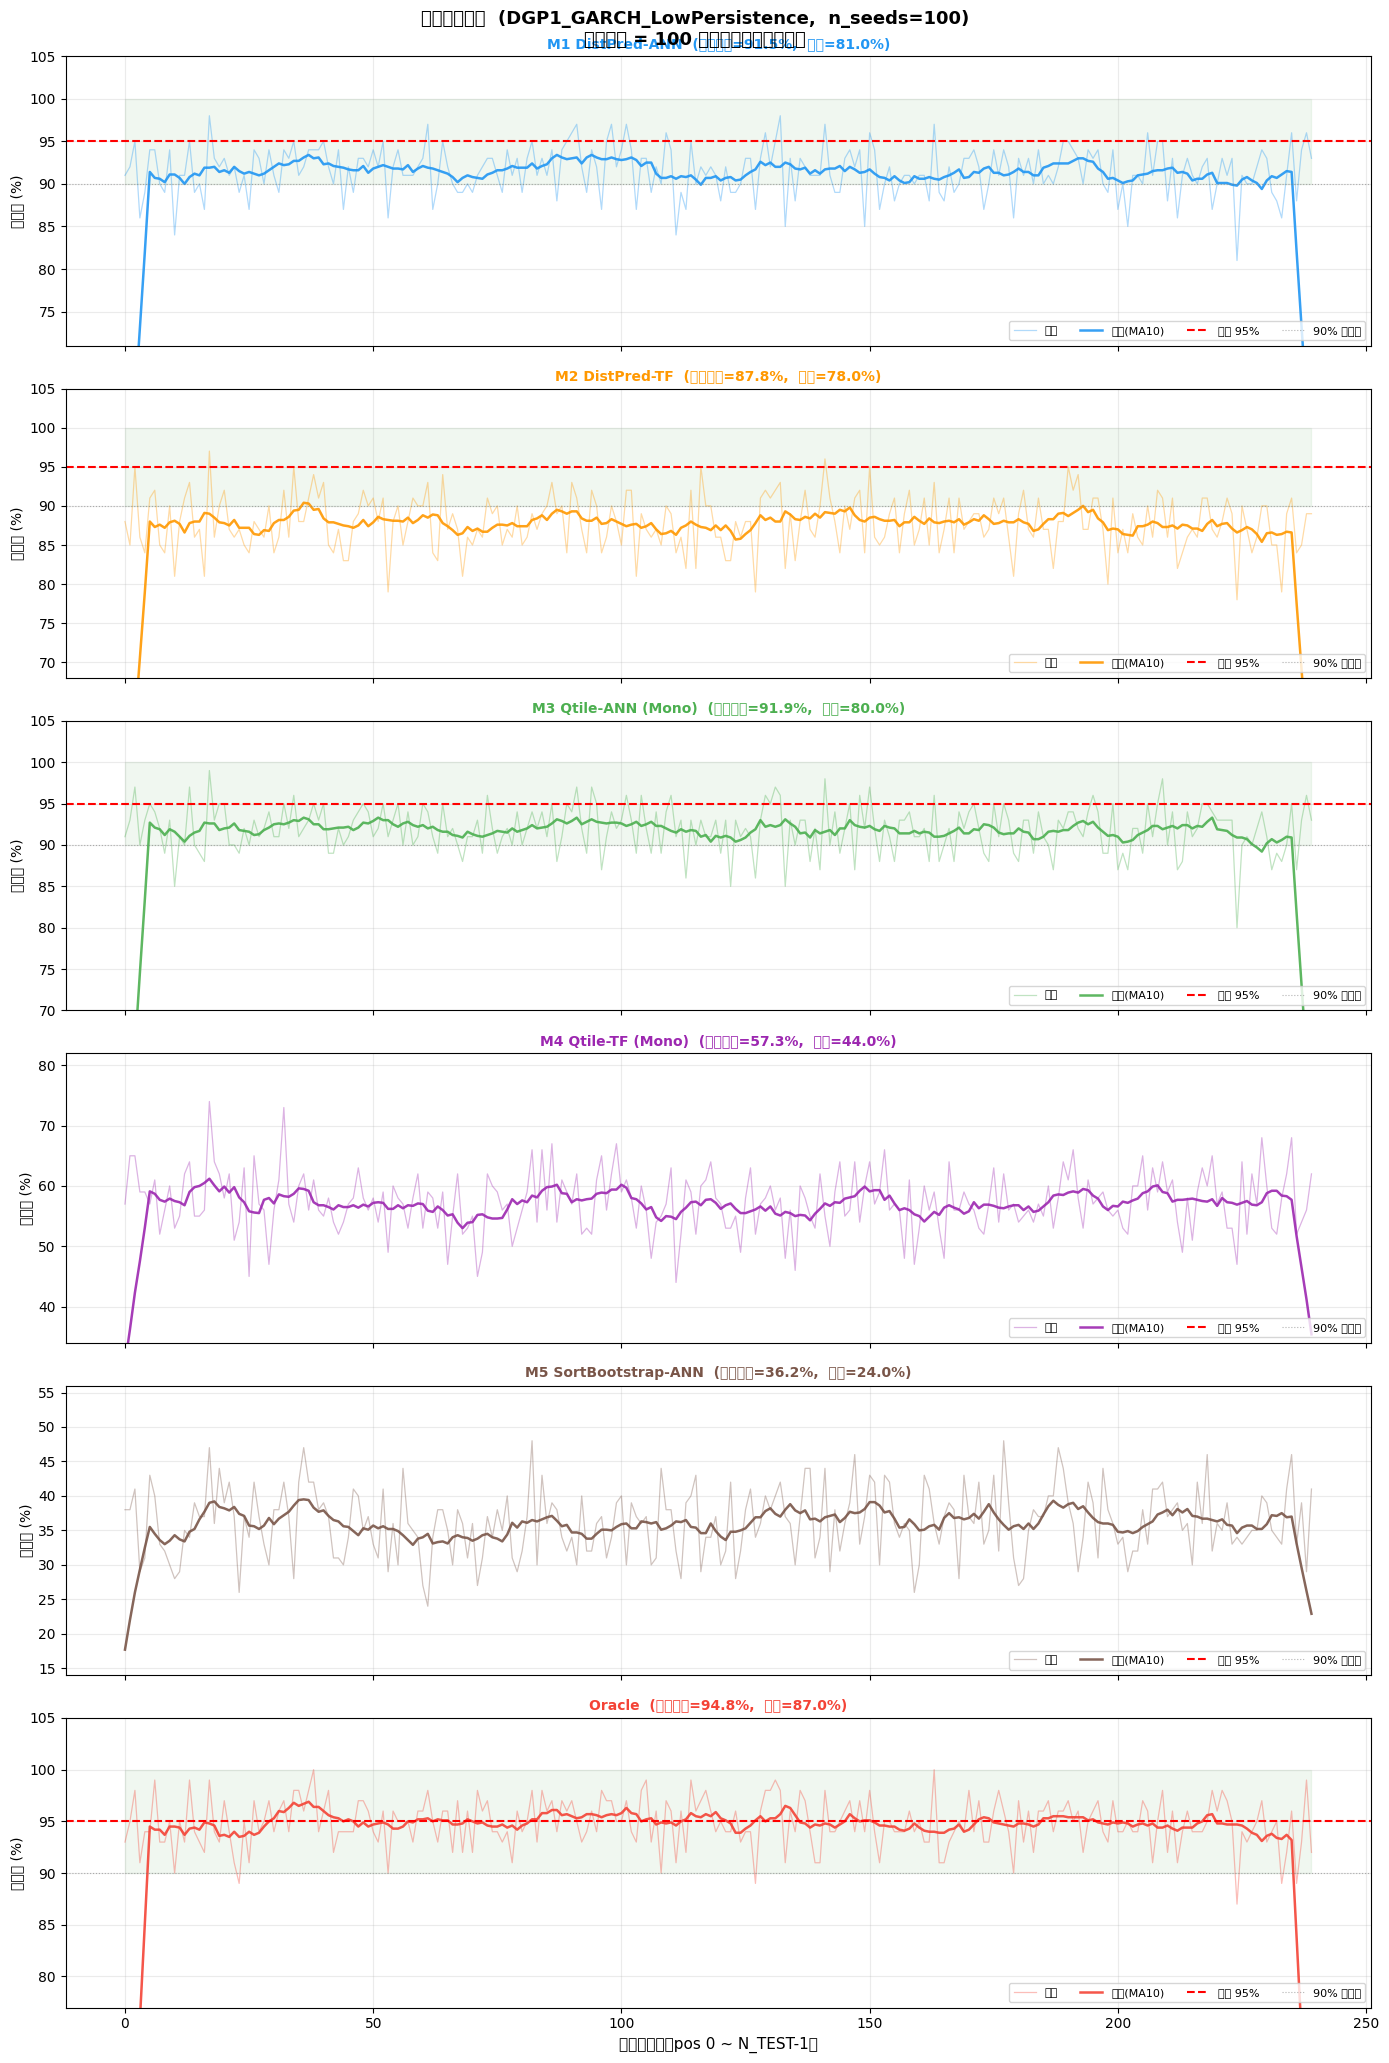

  ✅ 已儲存: ./sim_results_v3/pos_coverage_DGP1_GARCH_LowPersistence.png


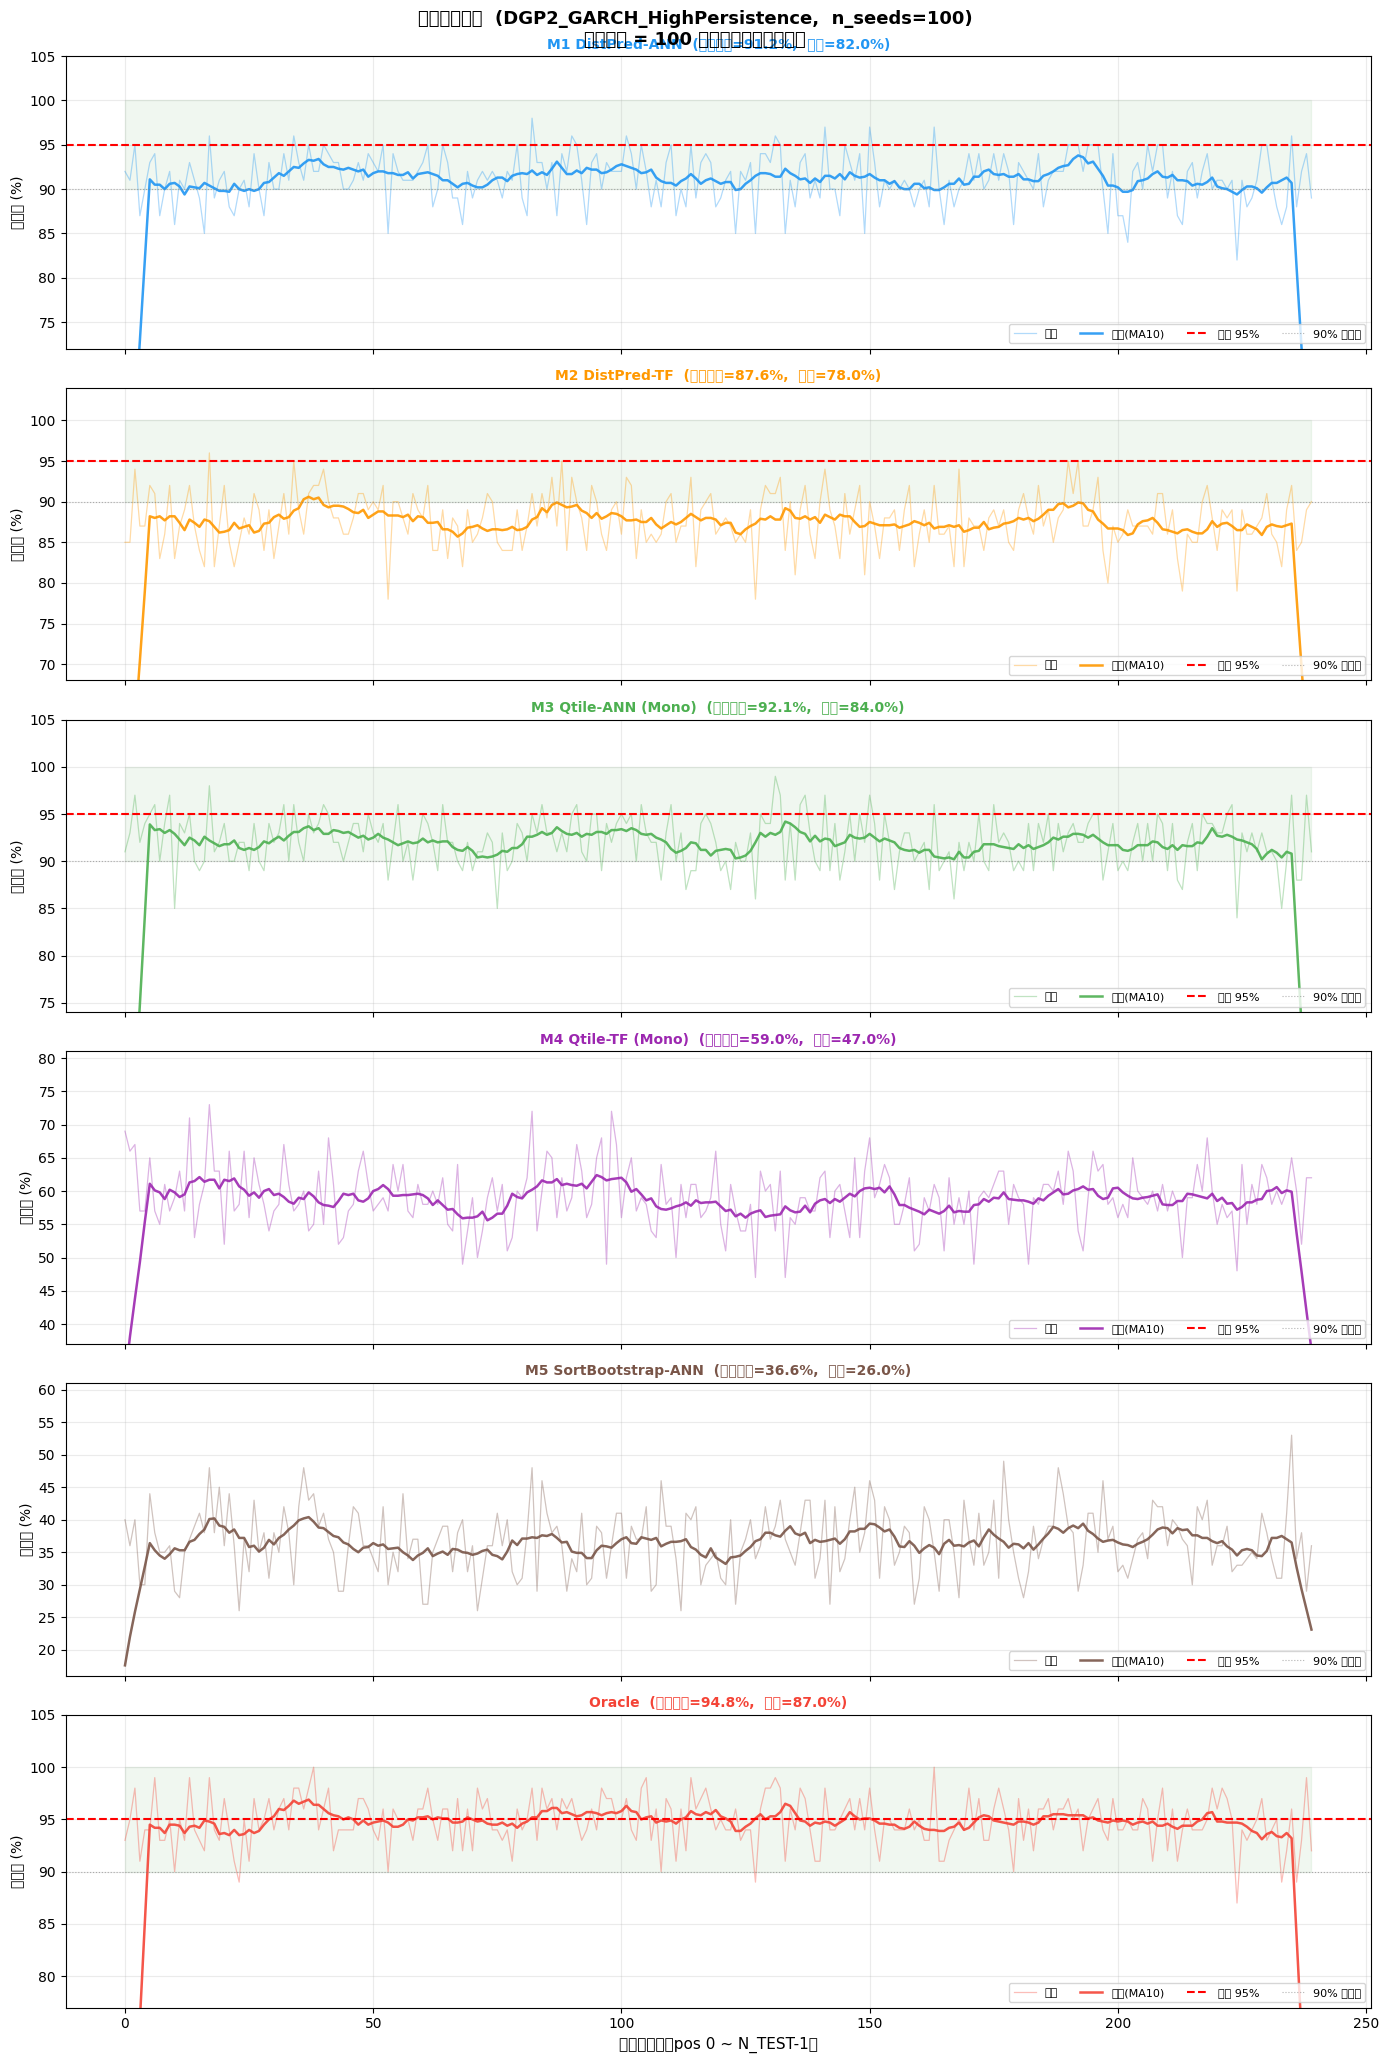

  ✅ 已儲存: ./sim_results_v3/pos_coverage_DGP2_GARCH_HighPersistence.png


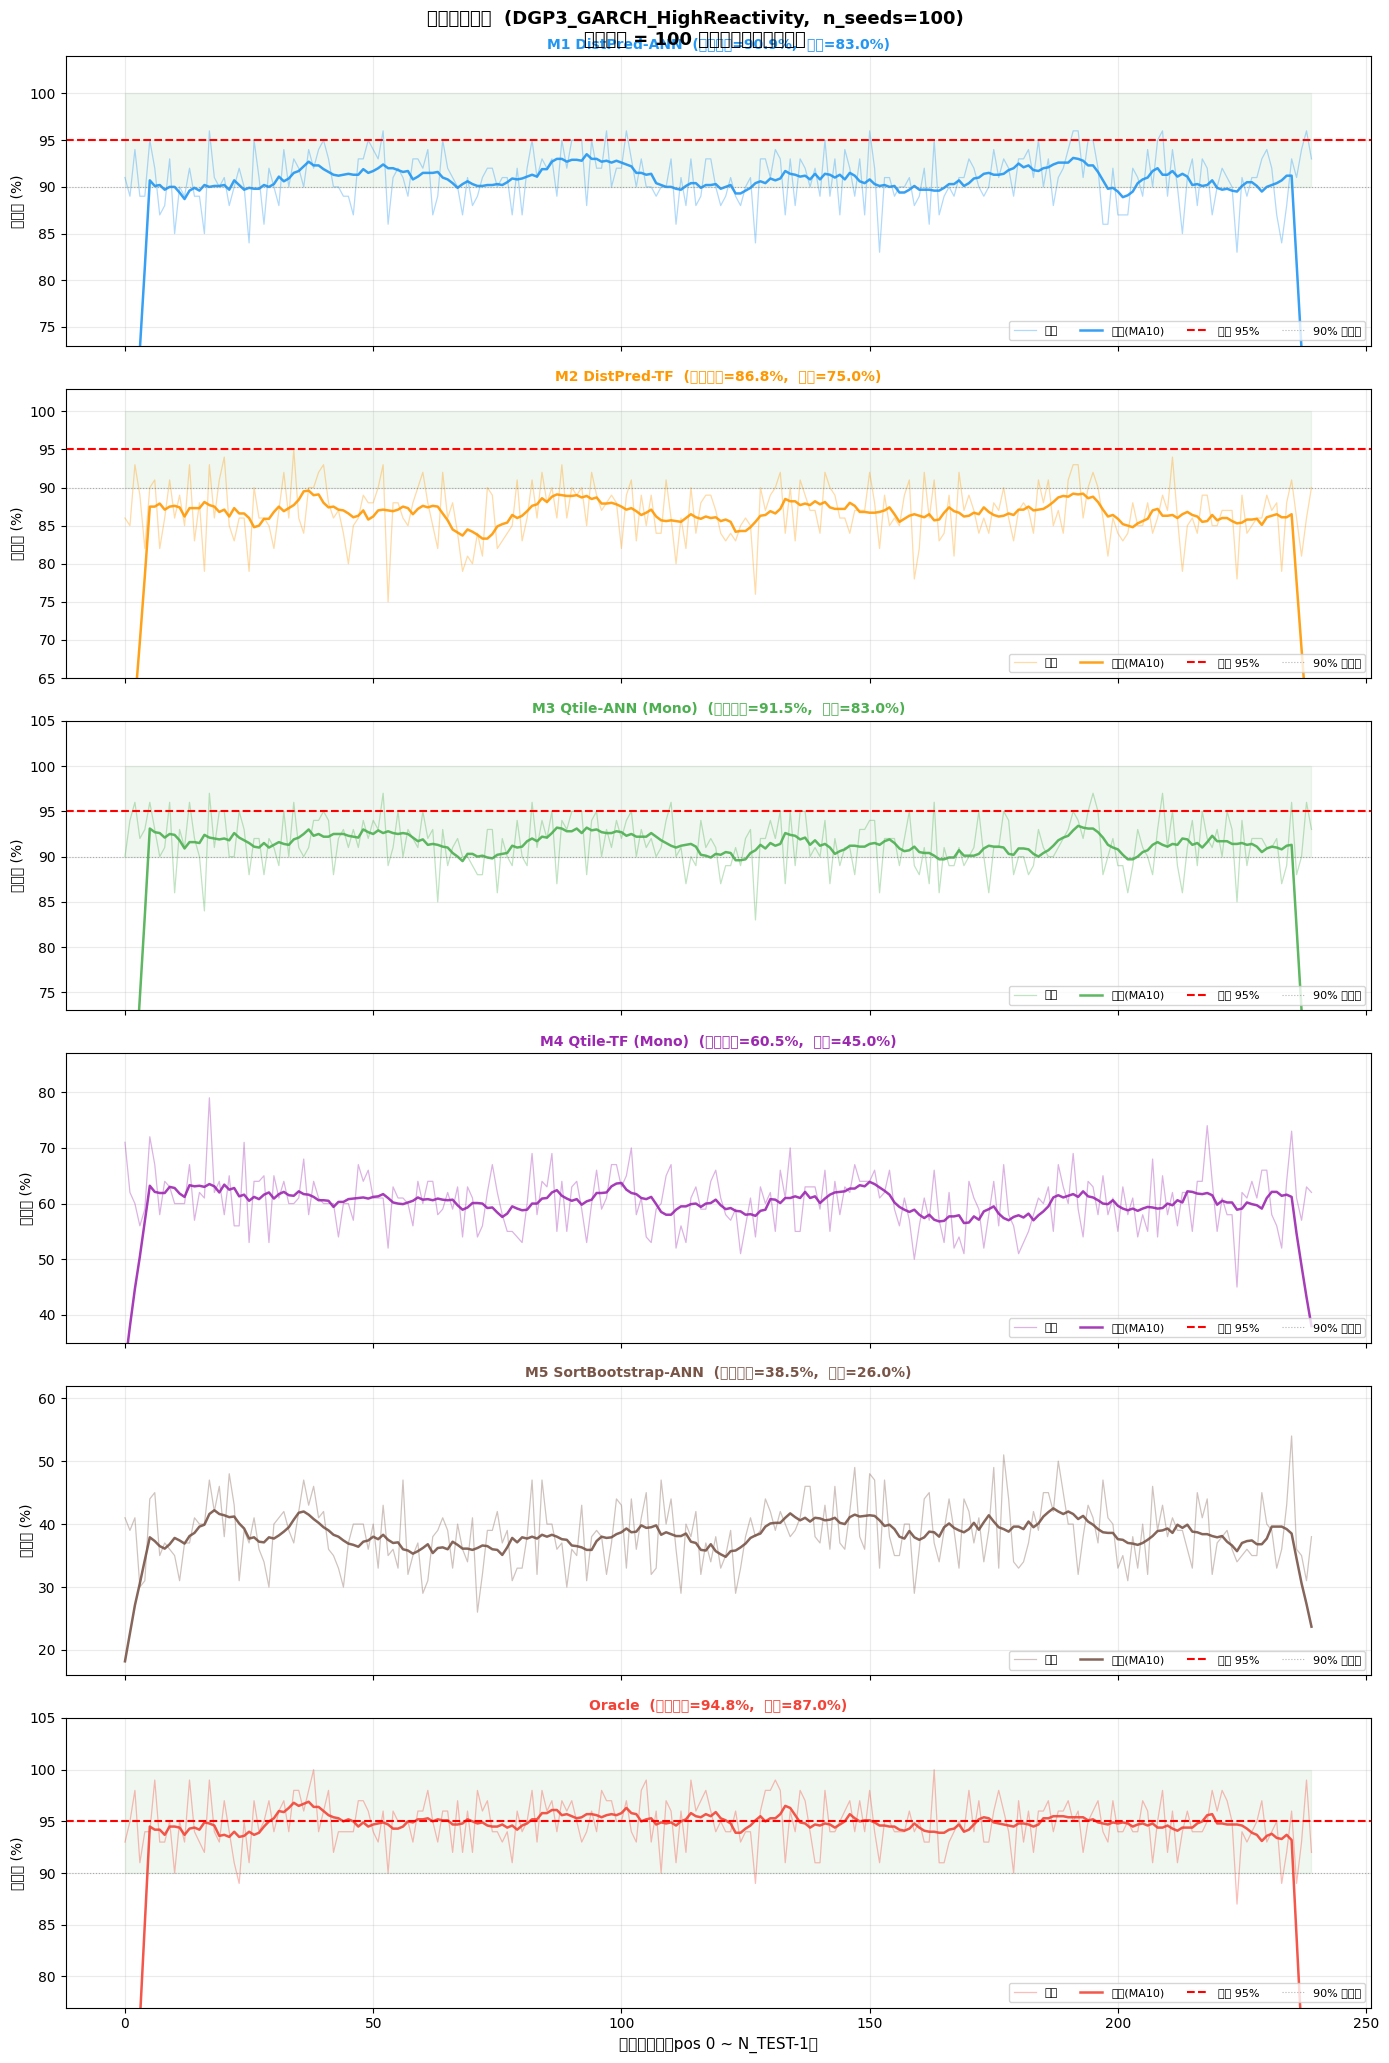

  ✅ 已儲存: ./sim_results_v3/pos_coverage_DGP3_GARCH_HighReactivity.png


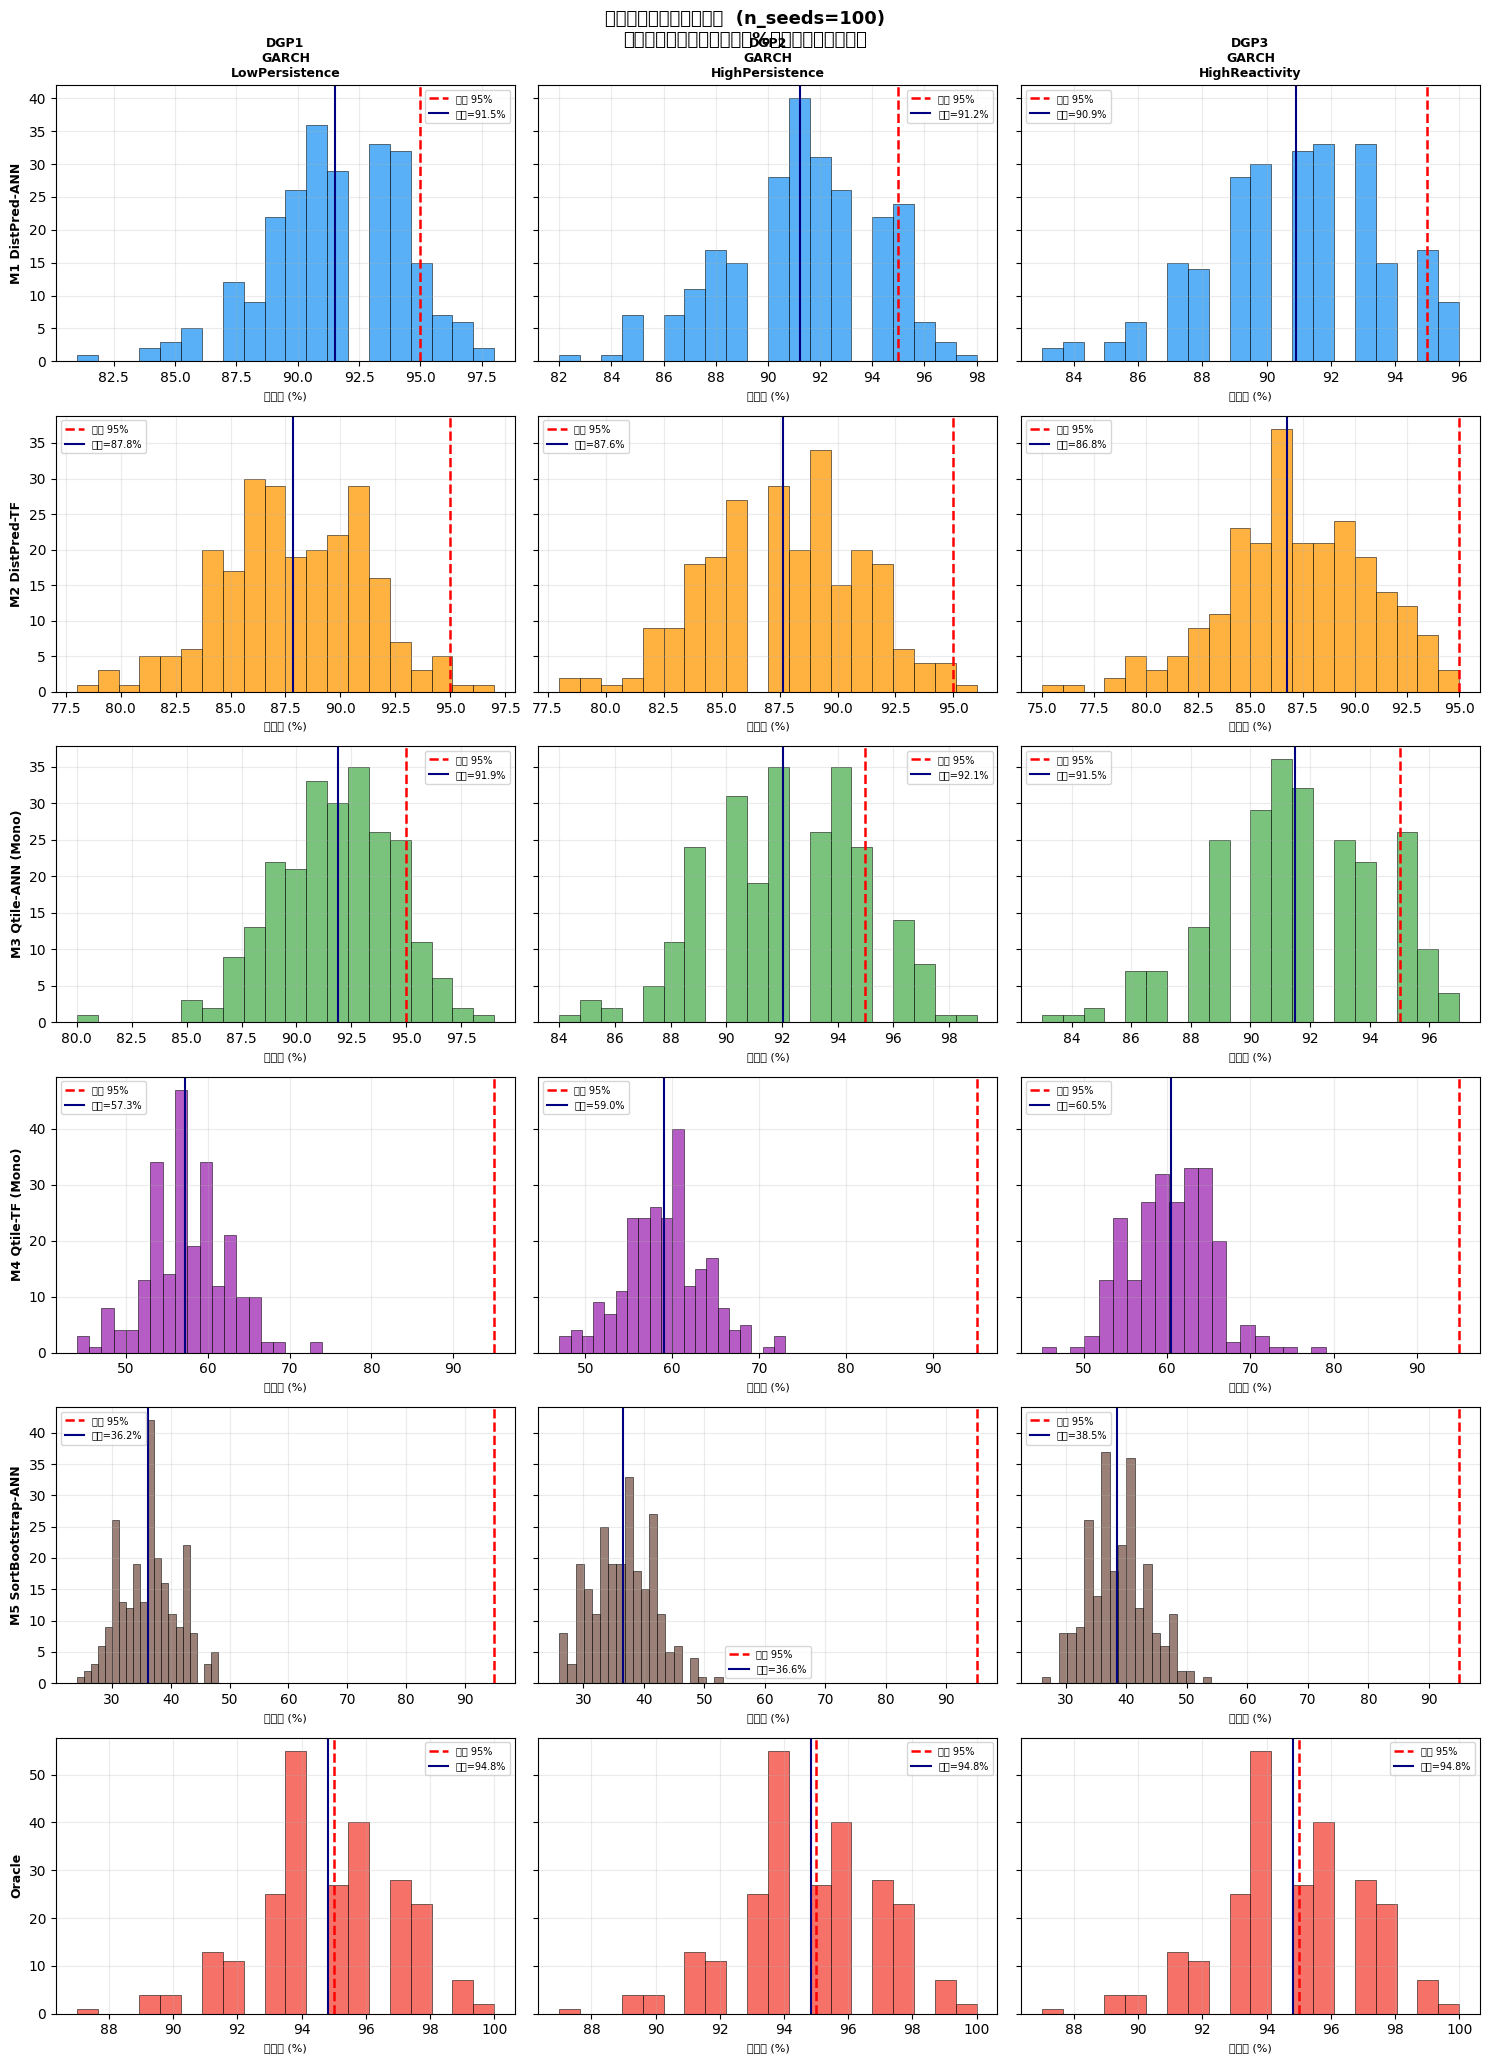

✅ 已儲存: ./sim_results_v3/pos_coverage_hist_all.png


In [17]:
METHOD_COLORS = {
    'M1_DistPred_ANN'                  : '#2196F3',
    'M2_DistPred_Minusformer'          : '#FF9800',
    'M3_QuantileANN_Monotone'          : '#4CAF50',
    'M4_QuantileMinusformer_Monotone'  : '#9C27B0',
    'M5_SortBootstrap_ANN'             : '#795548',
    'Oracle_Theoretical'               : '#F44336',
}
METHOD_SHORT = {
    'M1_DistPred_ANN'                  : 'M1 DistPred-ANN',
    'M2_DistPred_Minusformer'          : 'M2 DistPred-TF',
    'M3_QuantileANN_Monotone'          : 'M3 Qtile-ANN (Mono)',
    'M4_QuantileMinusformer_Monotone'  : 'M4 Qtile-TF (Mono)',
    'M5_SortBootstrap_ANN'             : 'M5 SortBootstrap-ANN',
    'Oracle_Theoretical'               : 'Oracle',
}

# 各 DGP：逐位置涵蓋率折線圖
for dgp in dgp_names:
    fig, axes = plt.subplots(len(methods), 1, figsize=(14, 3.5 * len(methods)),
                             sharex=True)
    fig.suptitle(f'逐位置涵蓋率  ({dgp},  n_seeds={cfg.n_seeds})\n'
                 f'每個位置 = {cfg.n_seeds} 次實驗中被涵蓋的比例',
                 fontsize=13, fontweight='bold')

    positions = np.arange(N_TEST)

    for ax, method in zip(axes, methods):
        cov    = covered_matrices[dgp][method].mean(axis=0) * 100
        color  = METHOD_COLORS.get(method, 'gray')
        kernel = np.ones(10) / 10
        cov_smooth = np.convolve(cov, kernel, mode='same')

        ax.plot(positions, cov,        color=color, alpha=0.35, lw=0.9, label='原始')
        ax.plot(positions, cov_smooth, color=color, alpha=0.90, lw=1.8, label='平滑(MA10)')
        ax.axhline(95, color='red',  lw=1.5, ls='--', label='目標 95%')
        ax.axhline(90, color='gray', lw=0.8, ls=':',  alpha=0.6, label='90% 警戒線')
        ax.fill_between(positions, 90, 100, alpha=0.06, color='green')
        ax.set_ylabel('涵蓋率 (%)', fontsize=10)
        ax.set_title(f'{METHOD_SHORT.get(method, method)}  '
                     f'(位置均值={cov.mean():.1f}%,  最低={cov.min():.1f}%)',
                     fontsize=10, color=color, fontweight='bold')
        ax.set_ylim(max(0, cov.min() - 10), min(105, cov.max() + 8))
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc='lower right', ncol=4)

    axes[-1].set_xlabel('測試集位置（pos 0 ~ N_TEST-1）', fontsize=11)
    plt.tight_layout()
    fname = f'{cfg.output_dir}/pos_coverage_{dgp}.png'
    if cfg.save_plots:
        plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"  ✅ 已儲存: {fname}")


# 各方法涵蓋率分布直方圖
fig, axes = plt.subplots(len(methods), len(dgp_names),
                         figsize=(5 * len(dgp_names), 3.5 * len(methods)),
                         sharey='row')
fig.suptitle(f'各位置涵蓋率分布直方圖  (n_seeds={cfg.n_seeds})\n'
             f'橫軸：某個位置的涵蓋率（%），縱軸：位置數量',
             fontsize=13, fontweight='bold')

for row, method in enumerate(methods):
    for col, dgp in enumerate(dgp_names):
        ax    = axes[row, col]
        cov   = covered_matrices[dgp][method].mean(axis=0) * 100
        color = METHOD_COLORS.get(method, 'gray')

        ax.hist(cov, bins=20, color=color, alpha=0.75, edgecolor='black', lw=0.5)
        ax.axvline(95, color='red',  lw=1.8, ls='--', label='目標 95%')
        ax.axvline(cov.mean(), color='navy', lw=1.5, ls='-',
                   label=f'均值={cov.mean():.1f}%')
        if row == 0:
            ax.set_title(dgp.replace('_', '\n'), fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(METHOD_SHORT.get(method, method), fontsize=9, fontweight='bold')
        ax.set_xlabel('涵蓋率 (%)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)

plt.tight_layout()
fname = f'{cfg.output_dir}/pos_coverage_hist_all.png'
if cfg.save_plots:
    plt.savefig(fname, dpi=180, bbox_inches='tight')
plt.show()
print(f"✅ 已儲存: {fname}")

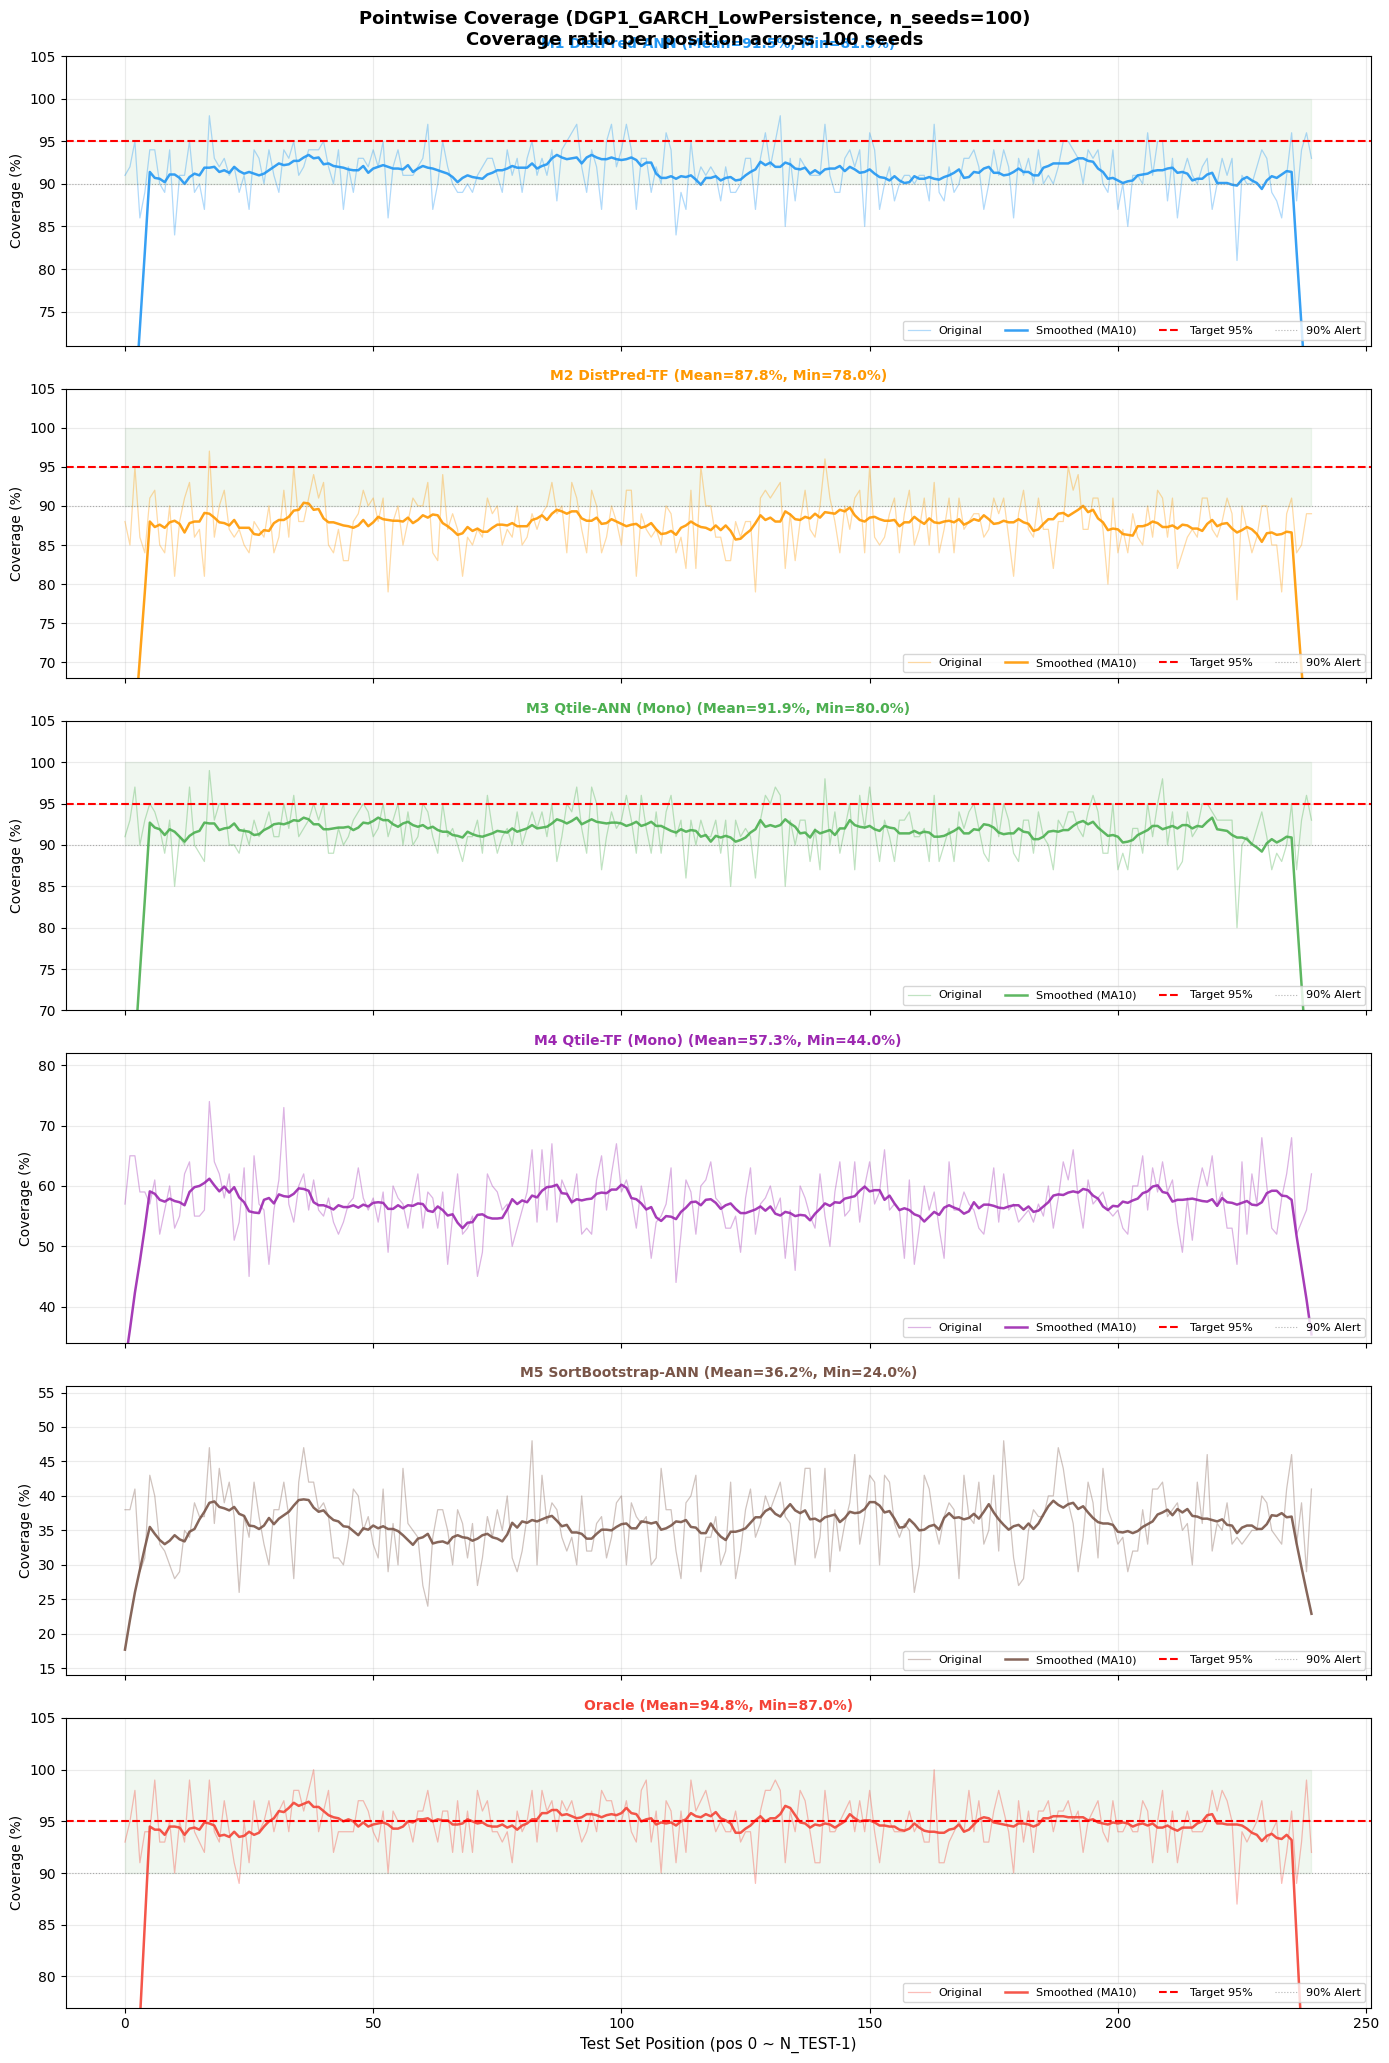

  ✅ Saved: ./sim_results_v3/pos_coverage_DGP1_GARCH_LowPersistence.png


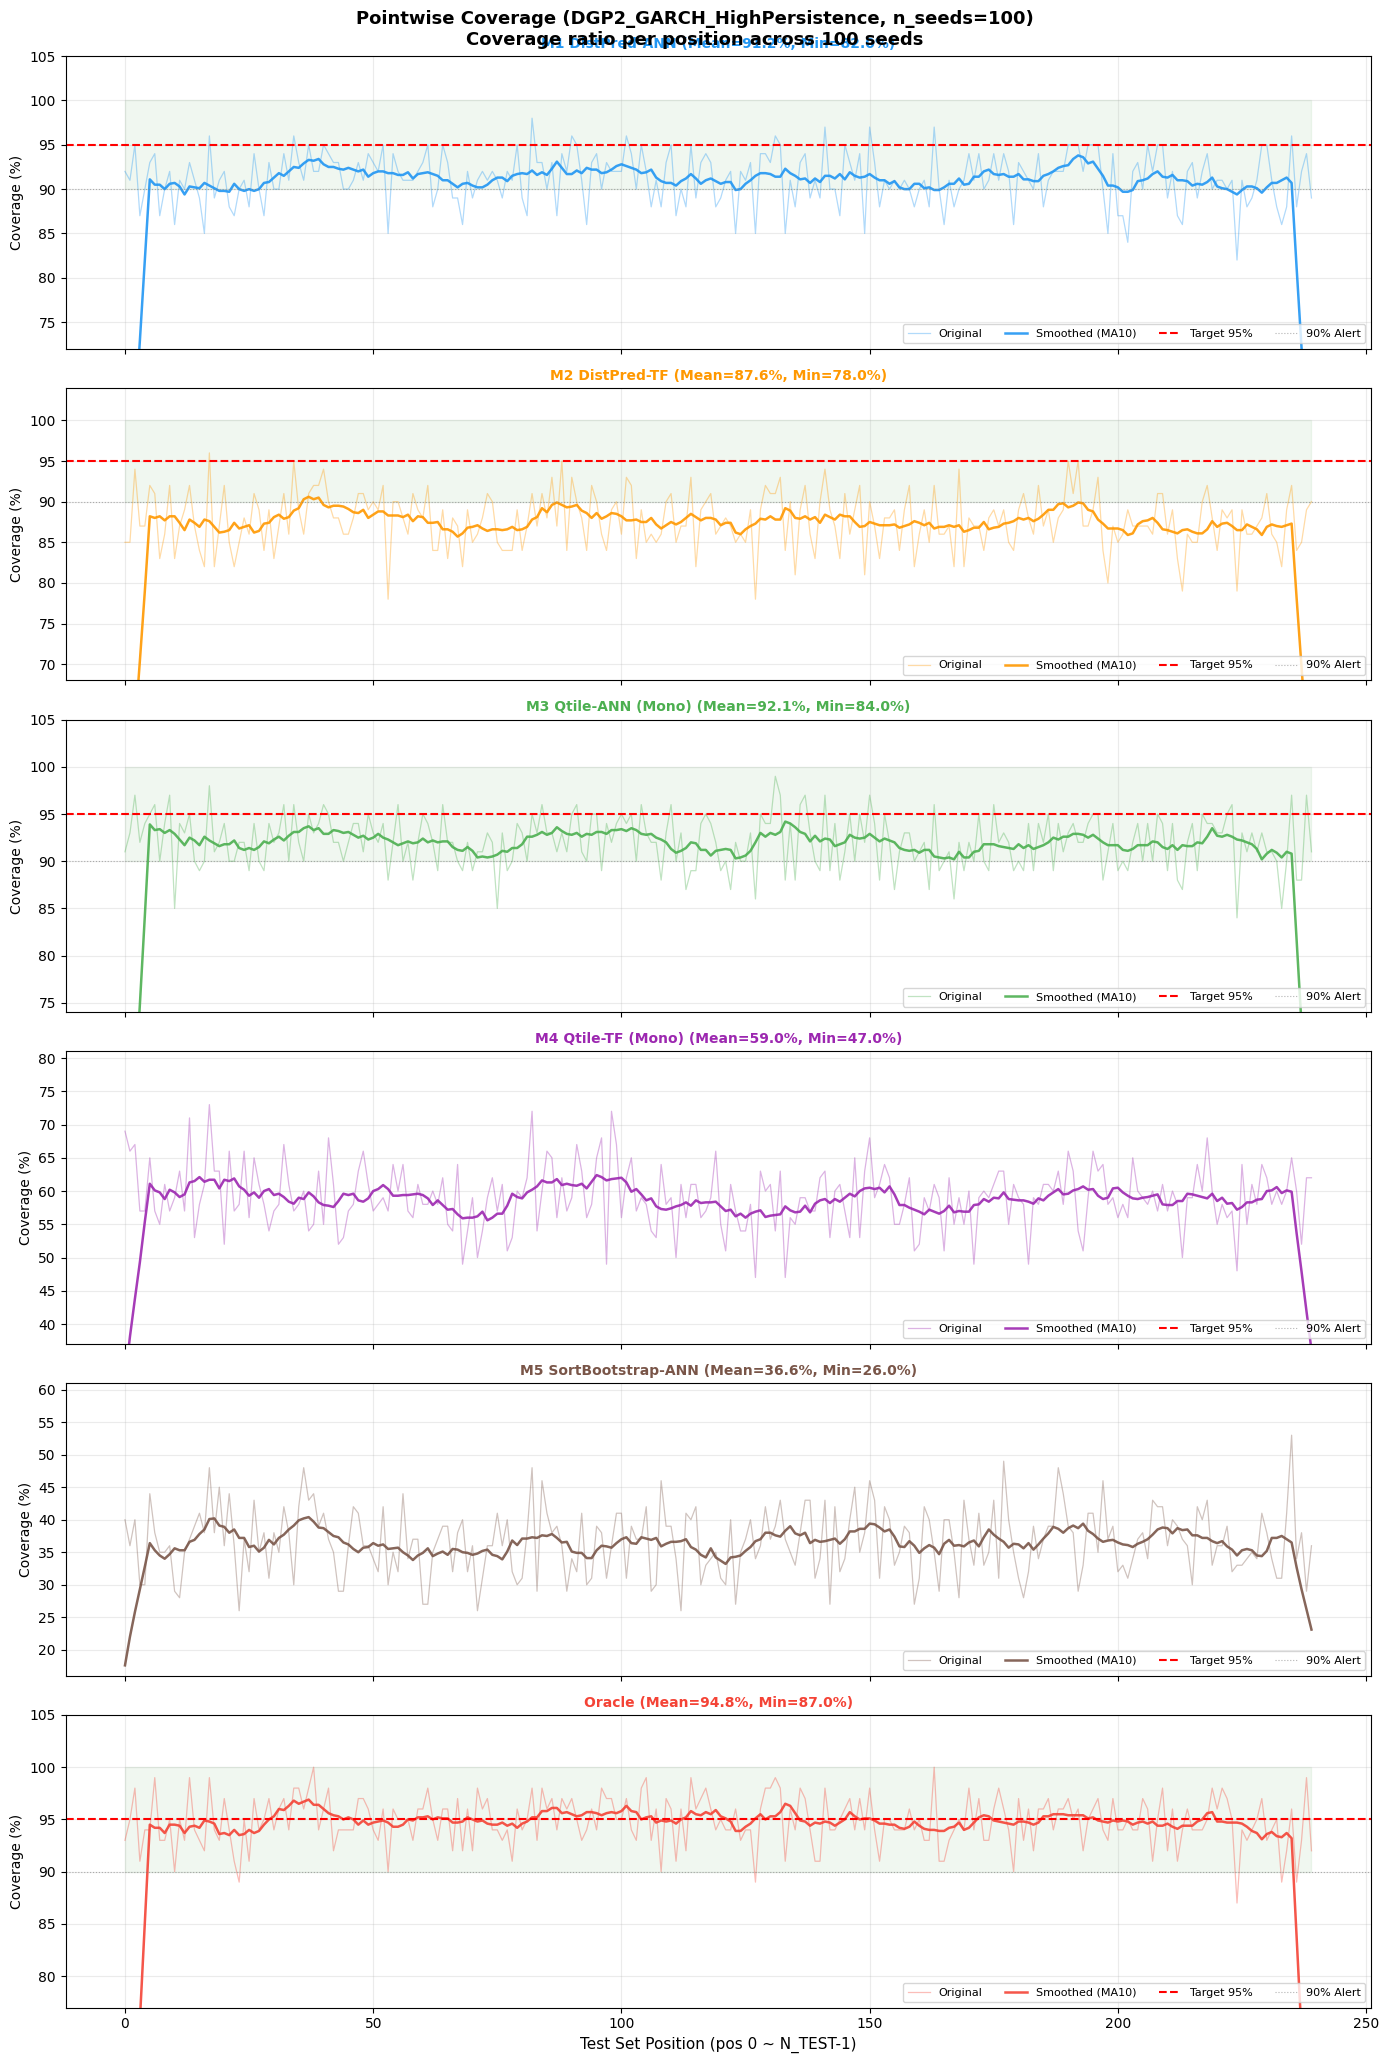

  ✅ Saved: ./sim_results_v3/pos_coverage_DGP2_GARCH_HighPersistence.png


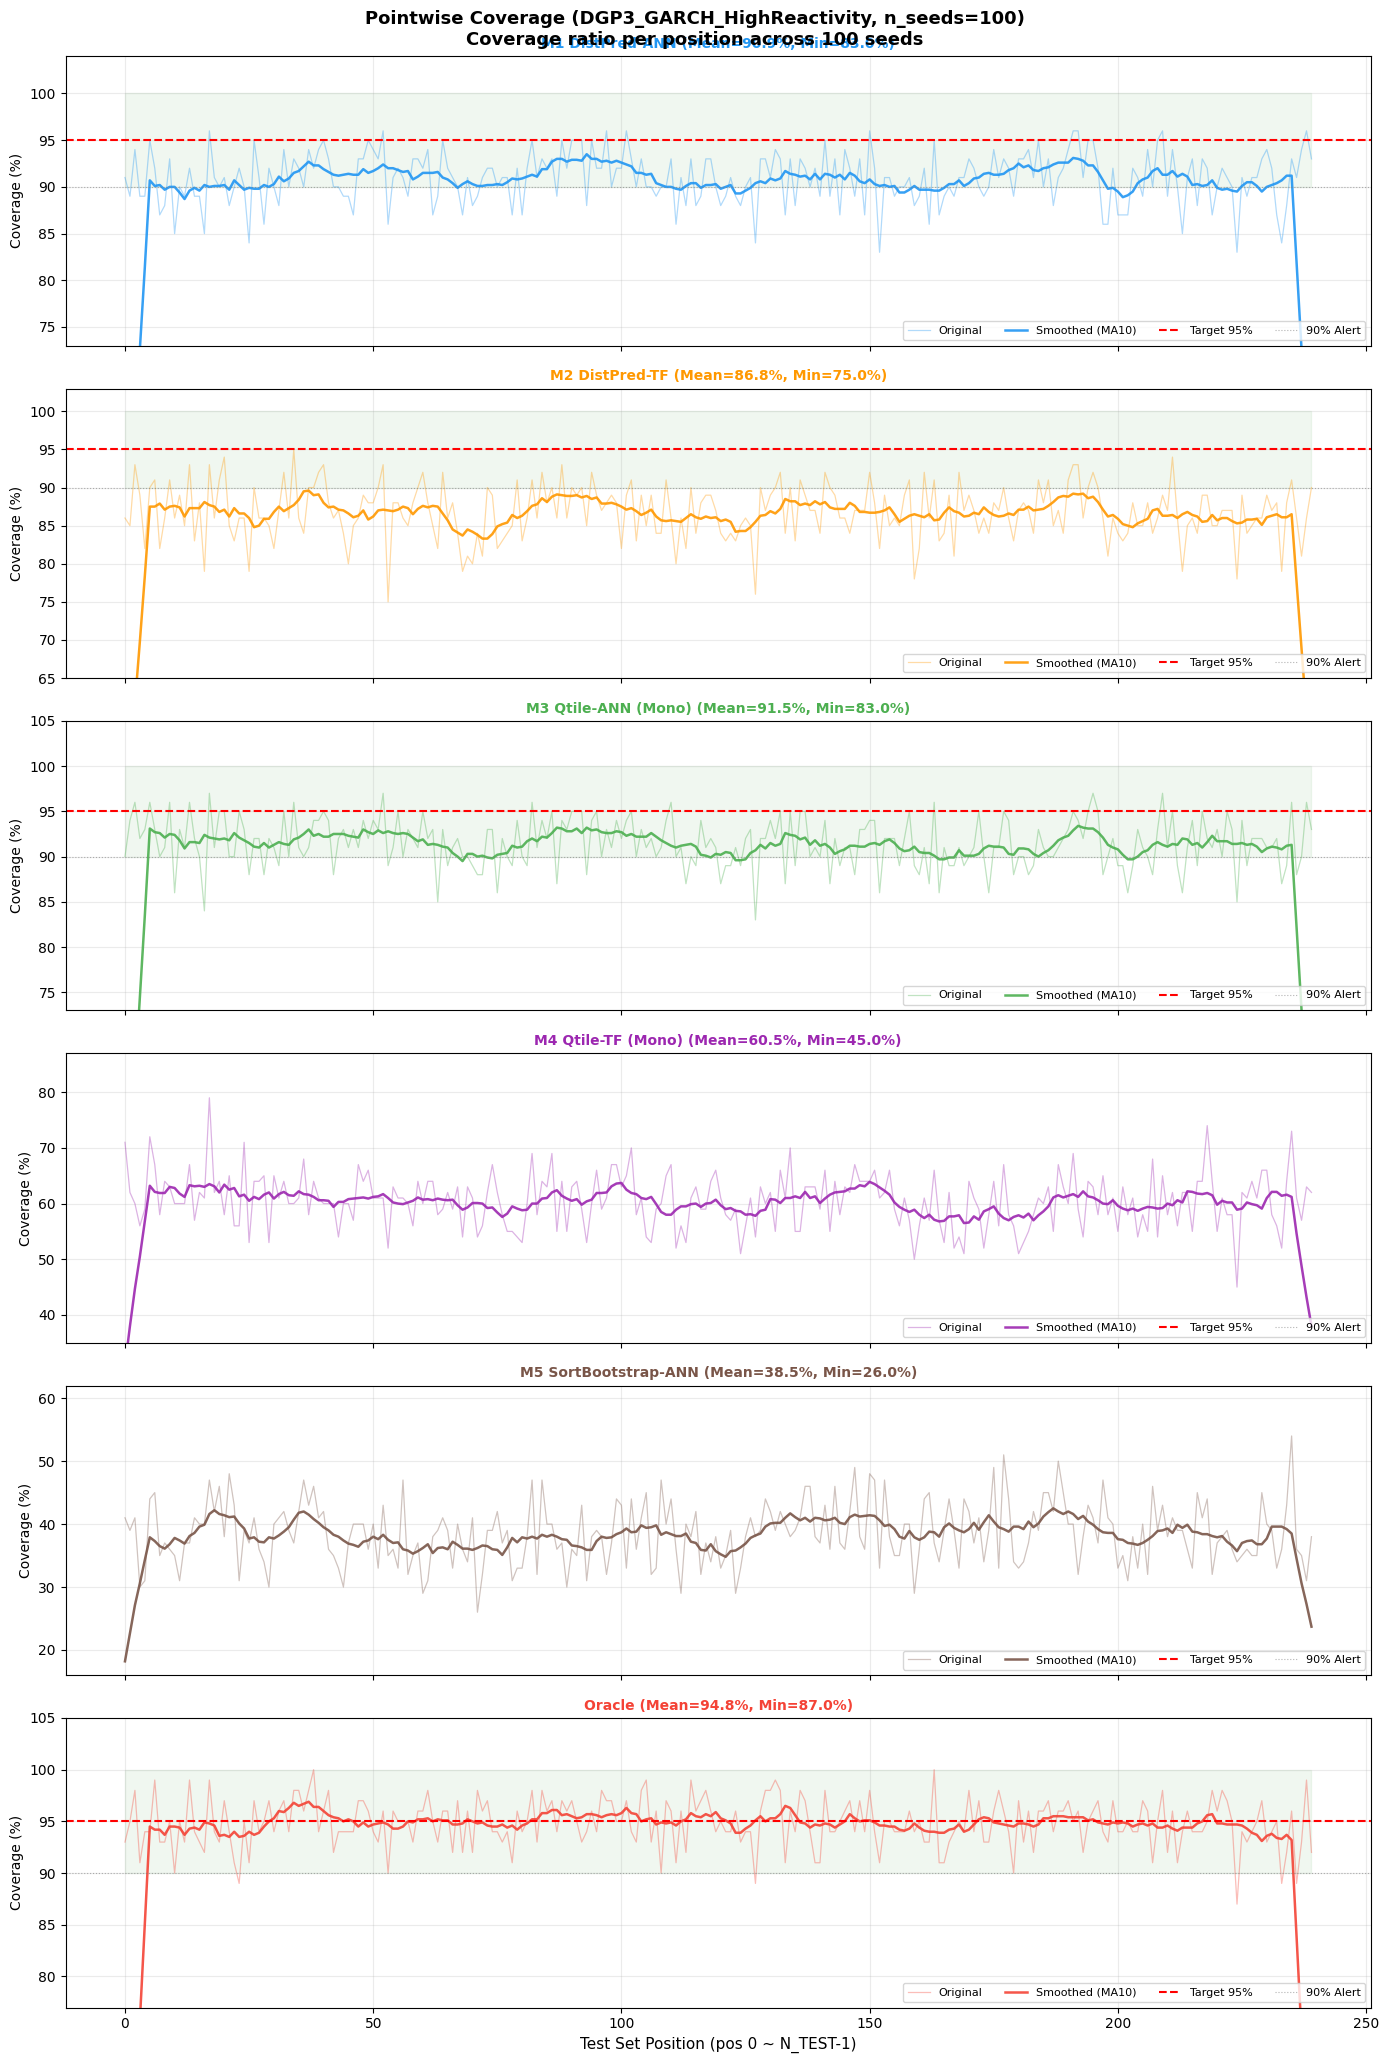

  ✅ Saved: ./sim_results_v3/pos_coverage_DGP3_GARCH_HighReactivity.png


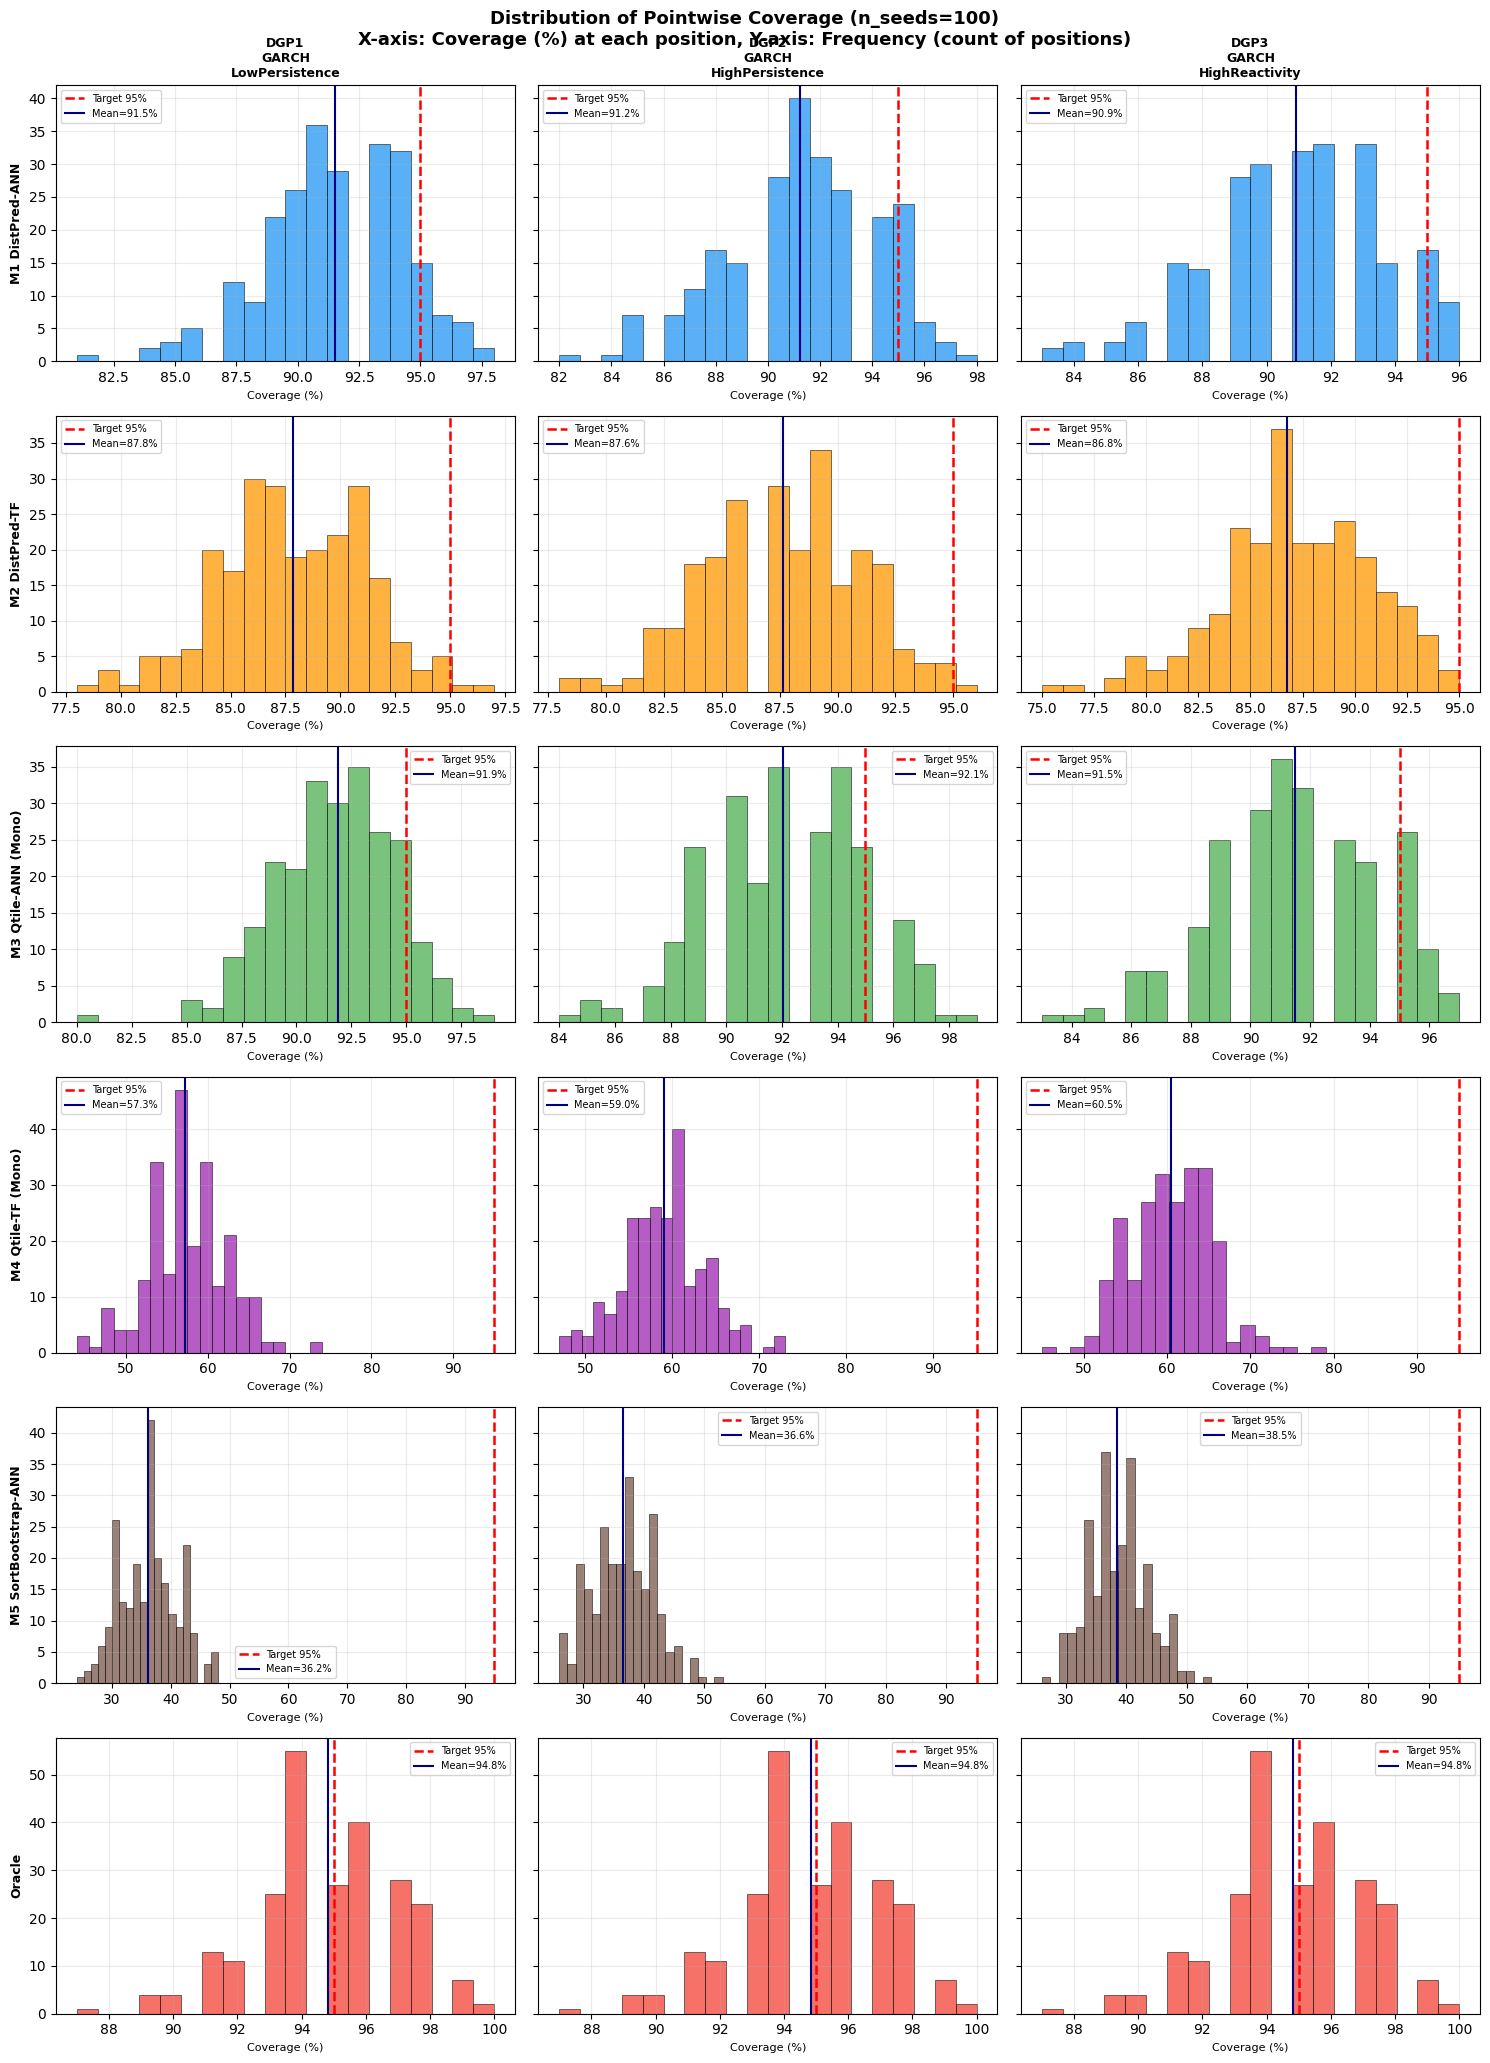

✅ Saved: ./sim_results_v3/pos_coverage_hist_all.png


In [22]:
METHOD_COLORS = {
    'M1_DistPred_ANN'                  : '#2196F3',
    'M2_DistPred_Minusformer'          : '#FF9800',
    'M3_QuantileANN_Monotone'          : '#4CAF50',
    'M4_QuantileMinusformer_Monotone'  : '#9C27B0',
    'M5_SortBootstrap_ANN'             : '#795548',
    'Oracle_Theoretical'               : '#F44336',
}
METHOD_SHORT = {
    'M1_DistPred_ANN'                  : 'M1 DistPred-ANN',
    'M2_DistPred_Minusformer'          : 'M2 DistPred-TF',
    'M3_QuantileANN_Monotone'          : 'M3 Qtile-ANN (Mono)',
    'M4_QuantileMinusformer_Monotone'  : 'M4 Qtile-TF (Mono)',
    'M5_SortBootstrap_ANN'             : 'M5 SortBootstrap-ANN',
    'Oracle_Theoretical'               : 'Oracle',
}

# --- Each DGP: Pointwise Coverage Line Plot ---
for dgp in dgp_names:
    fig, axes = plt.subplots(len(methods), 1, figsize=(14, 3.5 * len(methods)),
                             sharex=True)
    
    fig.suptitle(f'Pointwise Coverage ({dgp}, n_seeds={cfg.n_seeds})\n'
                 f'Coverage ratio per position across {cfg.n_seeds} seeds',
                 fontsize=13, fontweight='bold')

    positions = np.arange(N_TEST)

    for ax, method in zip(axes, methods):
        cov    = covered_matrices[dgp][method].mean(axis=0) * 100
        color  = METHOD_COLORS.get(method, 'gray')
        kernel = np.ones(10) / 10
        cov_smooth = np.convolve(cov, kernel, mode='same')

        ax.plot(positions, cov,        color=color, alpha=0.35, lw=0.9, label='Original')
        ax.plot(positions, cov_smooth, color=color, alpha=0.90, lw=1.8, label='Smoothed (MA10)')
        ax.axhline(95, color='red',  lw=1.5, ls='--', label='Target 95%')
        ax.axhline(90, color='gray', lw=0.8, ls=':',  alpha=0.6, label='90% Alert')
        ax.fill_between(positions, 90, 100, alpha=0.06, color='green')
        
        ax.set_ylabel('Coverage (%)', fontsize=10)
        ax.set_title(f'{METHOD_SHORT.get(method, method)} '
                     f'(Mean={cov.mean():.1f}%, Min={cov.min():.1f}%)',
                     fontsize=10, color=color, fontweight='bold')
        ax.set_ylim(max(0, cov.min() - 10), min(105, cov.max() + 8))
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc='lower right', ncol=4)

    axes[-1].set_xlabel('Test Set Position (pos 0 ~ N_TEST-1)', fontsize=11)
    plt.tight_layout()
    fname = f'{cfg.output_dir}/pos_coverage_{dgp}.png'
    if cfg.save_plots:
        plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved: {fname}")


# --- Distribution of Pointwise Coverage Histogram ---
fig, axes = plt.subplots(len(methods), len(dgp_names),
                         figsize=(5 * len(dgp_names), 3.5 * len(methods)),
                         sharey='row')

fig.suptitle(f'Distribution of Pointwise Coverage (n_seeds={cfg.n_seeds})\n'
             f'X-axis: Coverage (%) at each position, Y-axis: Frequency (count of positions)',
             fontsize=13, fontweight='bold')

for row, method in enumerate(methods):
    for col, dgp in enumerate(dgp_names):
        ax    = axes[row, col]
        cov   = covered_matrices[dgp][method].mean(axis=0) * 100
        color = METHOD_COLORS.get(method, 'gray')

        ax.hist(cov, bins=20, color=color, alpha=0.75, edgecolor='black', lw=0.5)
        ax.axvline(95, color='red',  lw=1.8, ls='--', label='Target 95%')
        ax.axvline(cov.mean(), color='navy', lw=1.5, ls='-',
                   label=f'Mean={cov.mean():.1f}%')
        
        if row == 0:
            ax.set_title(dgp.replace('_', '\n'), fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(METHOD_SHORT.get(method, method), fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Coverage (%)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)

plt.tight_layout()
fname = f'{cfg.output_dir}/pos_coverage_hist_all.png'
if cfg.save_plots:
    plt.savefig(fname, dpi=180, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fname}")


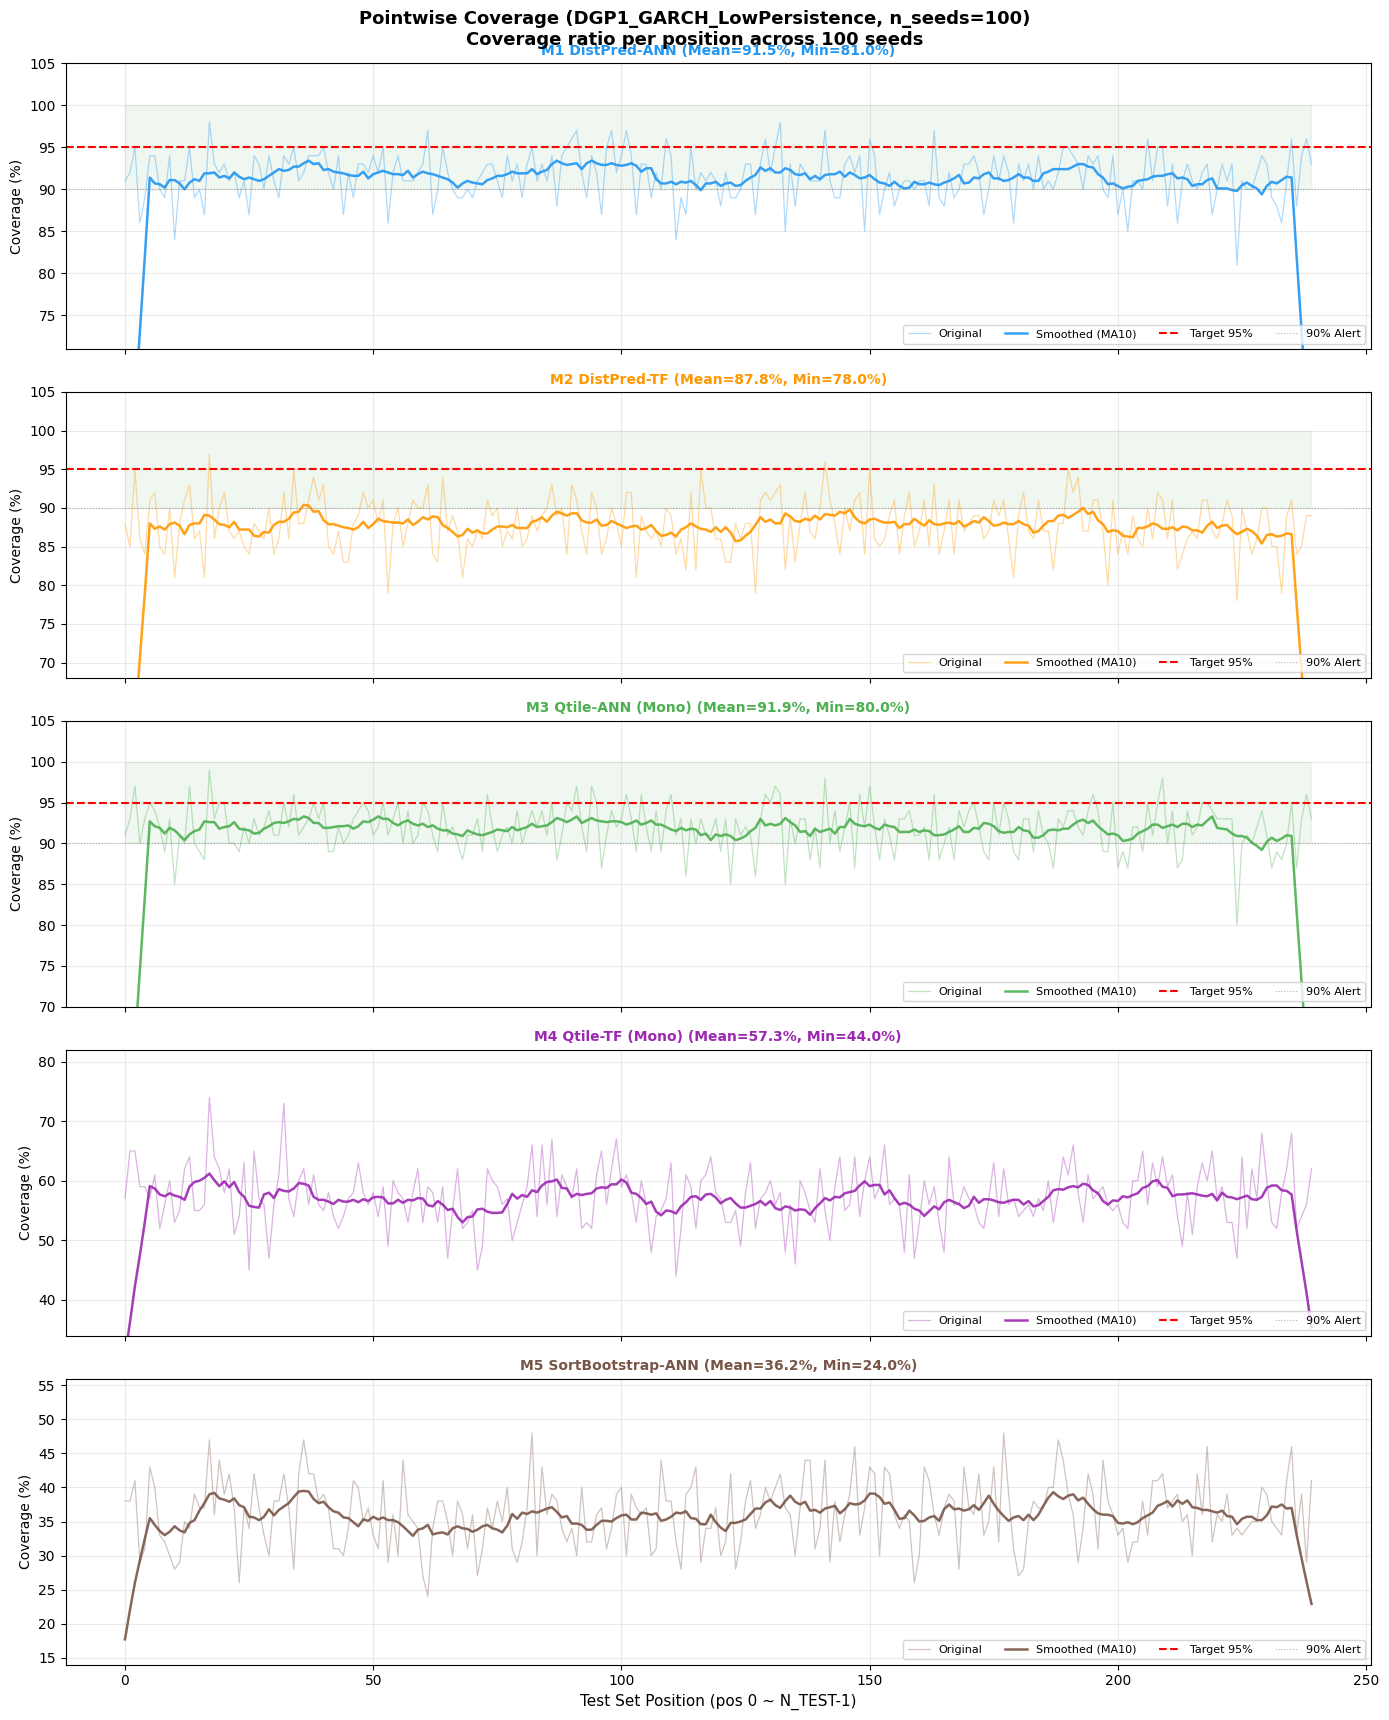

  ✅ Saved: ./sim_results_v3/pos_coverage_DGP1_GARCH_LowPersistence.png


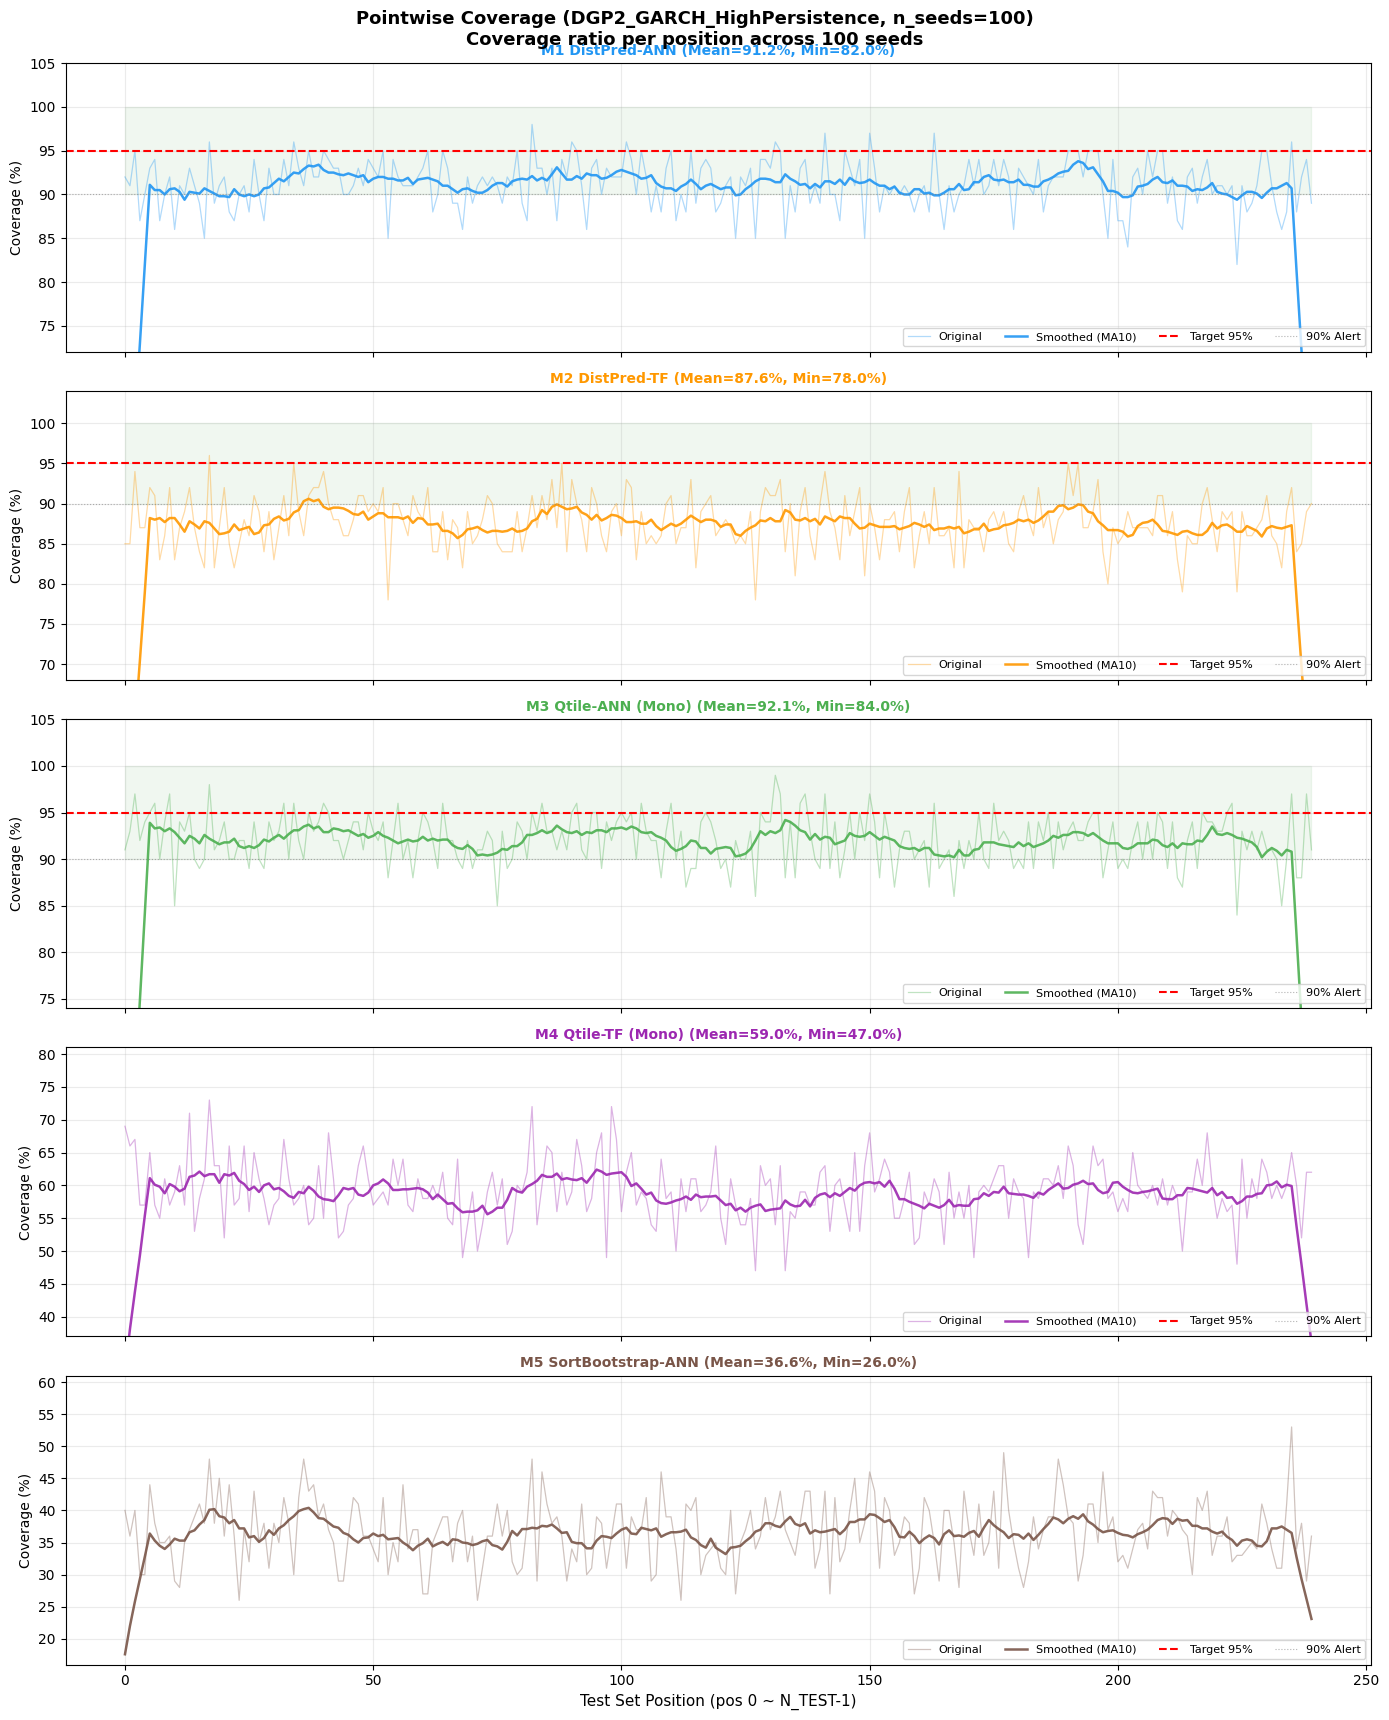

  ✅ Saved: ./sim_results_v3/pos_coverage_DGP2_GARCH_HighPersistence.png


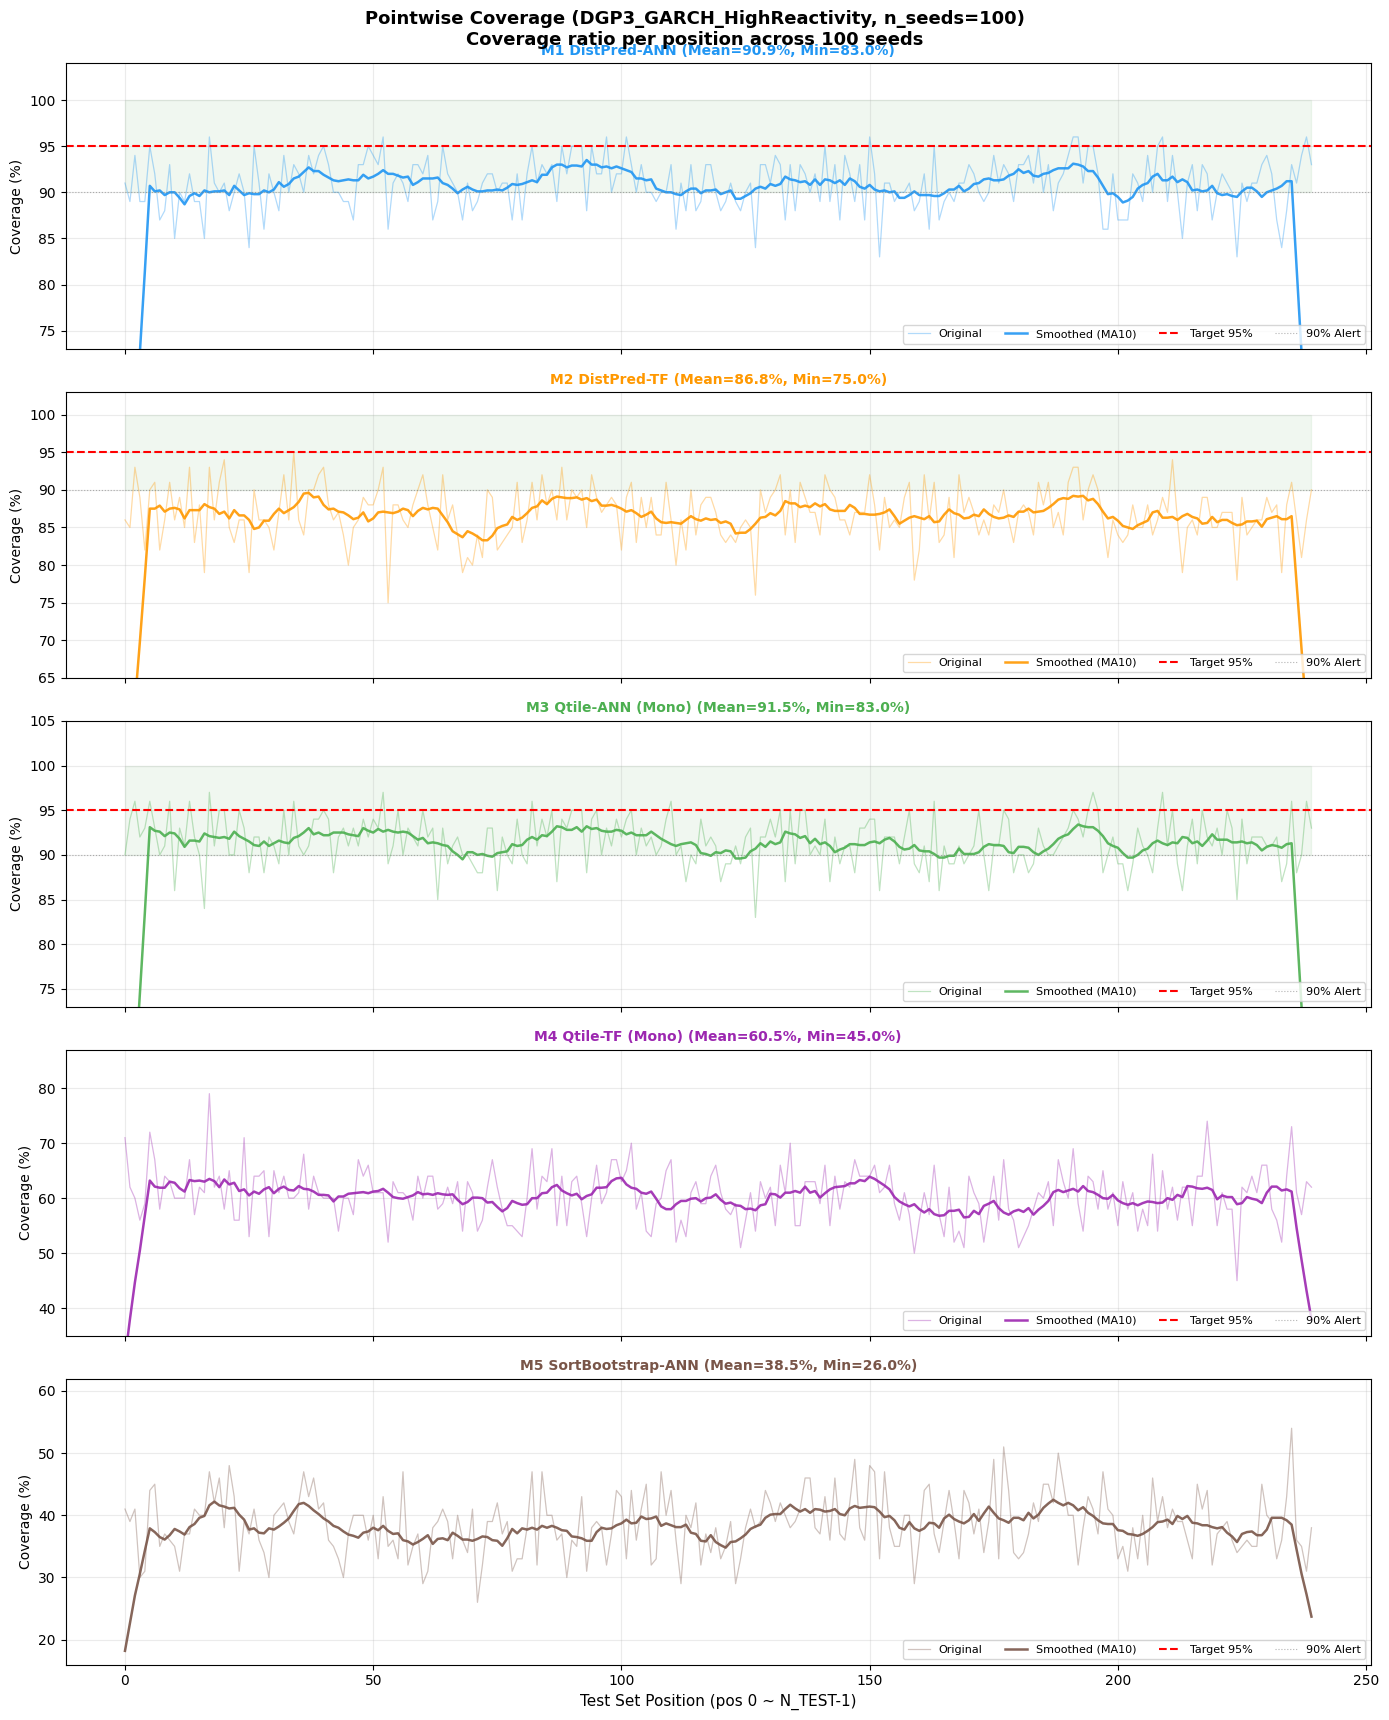

  ✅ Saved: ./sim_results_v3/pos_coverage_DGP3_GARCH_HighReactivity.png


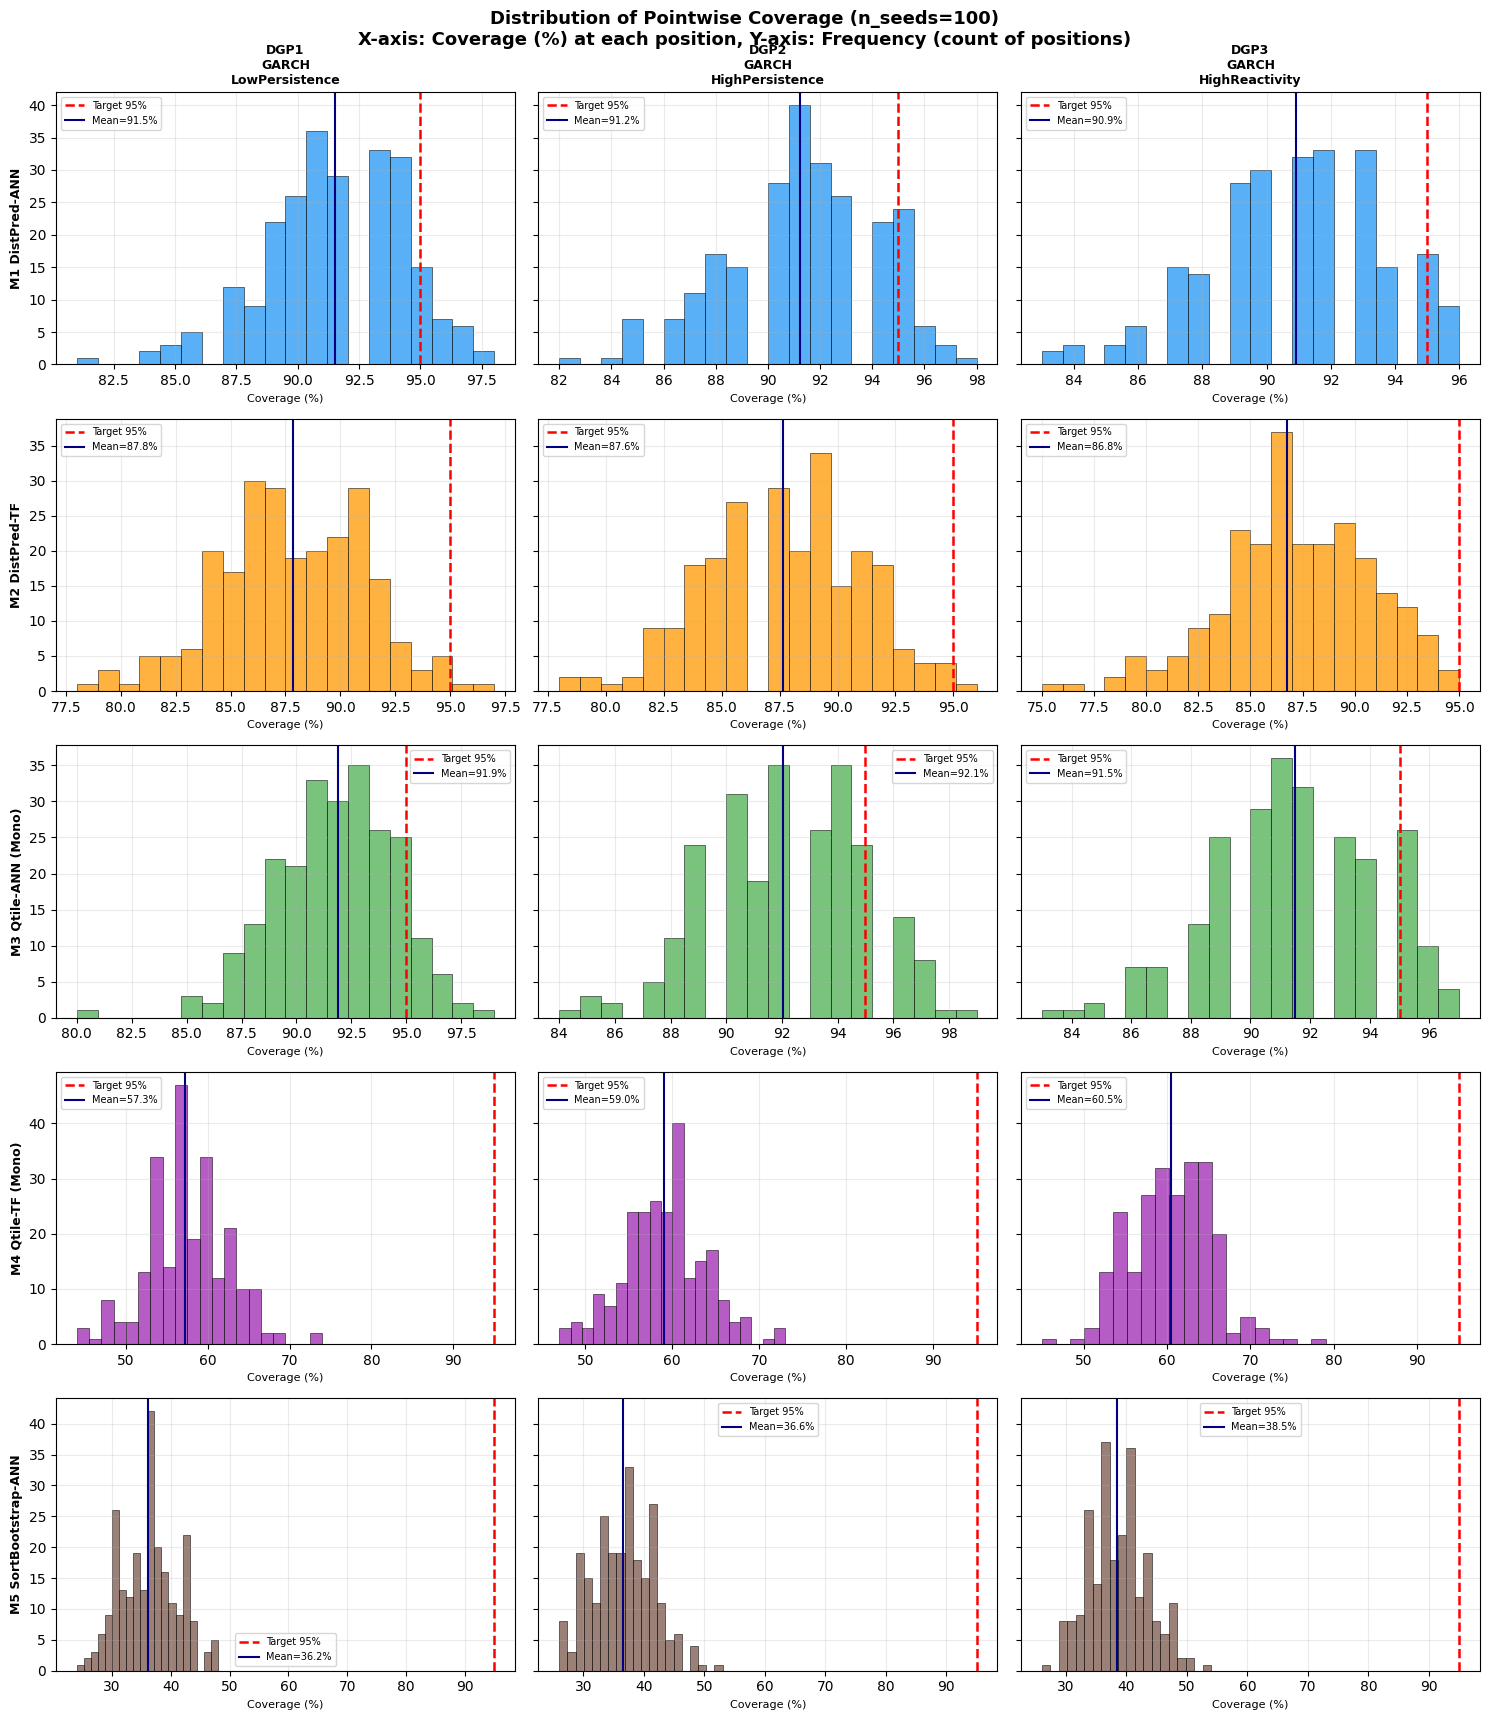

✅ Saved: ./sim_results_v3/pos_coverage_hist_all.png


In [21]:
METHOD_COLORS = {
    'M1_DistPred_ANN'                  : '#2196F3',
    'M2_DistPred_Minusformer'          : '#FF9800',
    'M3_QuantileANN_Monotone'          : '#4CAF50',
    'M4_QuantileMinusformer_Monotone'  : '#9C27B0',
    'M5_SortBootstrap_ANN'             : '#795548',
    'Oracle_Theoretical'               : '#F44336',
}
METHOD_SHORT = {
    'M1_DistPred_ANN'                  : 'M1 DistPred-ANN',
    'M2_DistPred_Minusformer'          : 'M2 DistPred-TF',
    'M3_QuantileANN_Monotone'          : 'M3 Qtile-ANN (Mono)',
    'M4_QuantileMinusformer_Monotone'  : 'M4 Qtile-TF (Mono)',
    'M5_SortBootstrap_ANN'             : 'M5 SortBootstrap-ANN',
    'Oracle_Theoretical'               : 'Oracle',
}

# 關鍵修改：定義一個不含 Oracle 的方法清單用於繪圖（剛好就是前面 5 種方法）
plot_methods = [m for m in methods if 'Oracle' not in m]

# --- 各 DGP：逐位置涵蓋率折線圖 (5 Methods) ---
for dgp in dgp_names:
    # 這裡的 len(methods) 改為 len(plot_methods)，讓畫布自動縮減為 5 列高度
    fig, axes = plt.subplots(len(plot_methods), 1, figsize=(14, 3.5 * len(plot_methods)),
                             sharex=True)
    
    fig.suptitle(f'Pointwise Coverage ({dgp}, n_seeds={cfg.n_seeds})\n'
                 f'Coverage ratio per position across {cfg.n_seeds} seeds',
                 fontsize=13, fontweight='bold')

    positions = np.arange(N_TEST)

    for ax, method in zip(axes, plot_methods):
        cov    = covered_matrices[dgp][method].mean(axis=0) * 100
        color  = METHOD_COLORS.get(method, 'gray')
        kernel = np.ones(10) / 10
        cov_smooth = np.convolve(cov, kernel, mode='same')

        ax.plot(positions, cov,        color=color, alpha=0.35, lw=0.9, label='Original')
        ax.plot(positions, cov_smooth, color=color, alpha=0.90, lw=1.8, label='Smoothed (MA10)')
        ax.axhline(95, color='red',  lw=1.5, ls='--', label='Target 95%')
        ax.axhline(90, color='gray', lw=0.8, ls=':',  alpha=0.6, label='90% Alert')
        ax.fill_between(positions, 90, 100, alpha=0.06, color='green')
        
        ax.set_ylabel('Coverage (%)', fontsize=10)
        ax.set_title(f'{METHOD_SHORT.get(method, method)} '
                     f'(Mean={cov.mean():.1f}%, Min={cov.min():.1f}%)',
                     fontsize=10, color=color, fontweight='bold')
        ax.set_ylim(max(0, cov.min() - 10), min(105, cov.max() + 8))
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8, loc='lower right', ncol=4)

    axes[-1].set_xlabel('Test Set Position (pos 0 ~ N_TEST-1)', fontsize=11)
    plt.tight_layout()
    fname = f'{cfg.output_dir}/pos_coverage_{dgp}.png'
    if cfg.save_plots:
        plt.savefig(fname, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved: {fname}")


# --- 各方法涵蓋率分布直方圖 (pos_coverage_hist_all.png - 5 Methods) ---
# 這裡同步改為 len(plot_methods)，徹底移除 Oracle 欄位
fig, axes = plt.subplots(len(plot_methods), len(dgp_names),
                         figsize=(5 * len(dgp_names), 3.5 * len(plot_methods)),
                         sharey='row')

fig.suptitle(f'Distribution of Pointwise Coverage (n_seeds={cfg.n_seeds})\n'
             f'X-axis: Coverage (%) at each position, Y-axis: Frequency (count of positions)',
             fontsize=13, fontweight='bold')

for row, method in enumerate(plot_methods):
    for col, dgp in enumerate(dgp_names):
        ax    = axes[row, col]
        cov   = covered_matrices[dgp][method].mean(axis=0) * 100
        color = METHOD_COLORS.get(method, 'gray')

        ax.hist(cov, bins=20, color=color, alpha=0.75, edgecolor='black', lw=0.5)
        ax.axvline(95, color='red',  lw=1.8, ls='--', label='Target 95%')
        ax.axvline(cov.mean(), color='navy', lw=1.5, ls='-',
                   label=f'Mean={cov.mean():.1f}%')
        
        if row == 0:
            ax.set_title(dgp.replace('_', '\n'), fontsize=9, fontweight='bold')
        if col == 0:
            ax.set_ylabel(METHOD_SHORT.get(method, method), fontsize=9, fontweight='bold')
        
        ax.set_xlabel('Coverage (%)', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.25)

plt.tight_layout()
fname = f'{cfg.output_dir}/pos_coverage_hist_all.png'
if cfg.save_plots:
    plt.savefig(fname, dpi=180, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {fname}")


## 16. 視覺化：整體 PICP 長條圖 + 偏差熱力圖

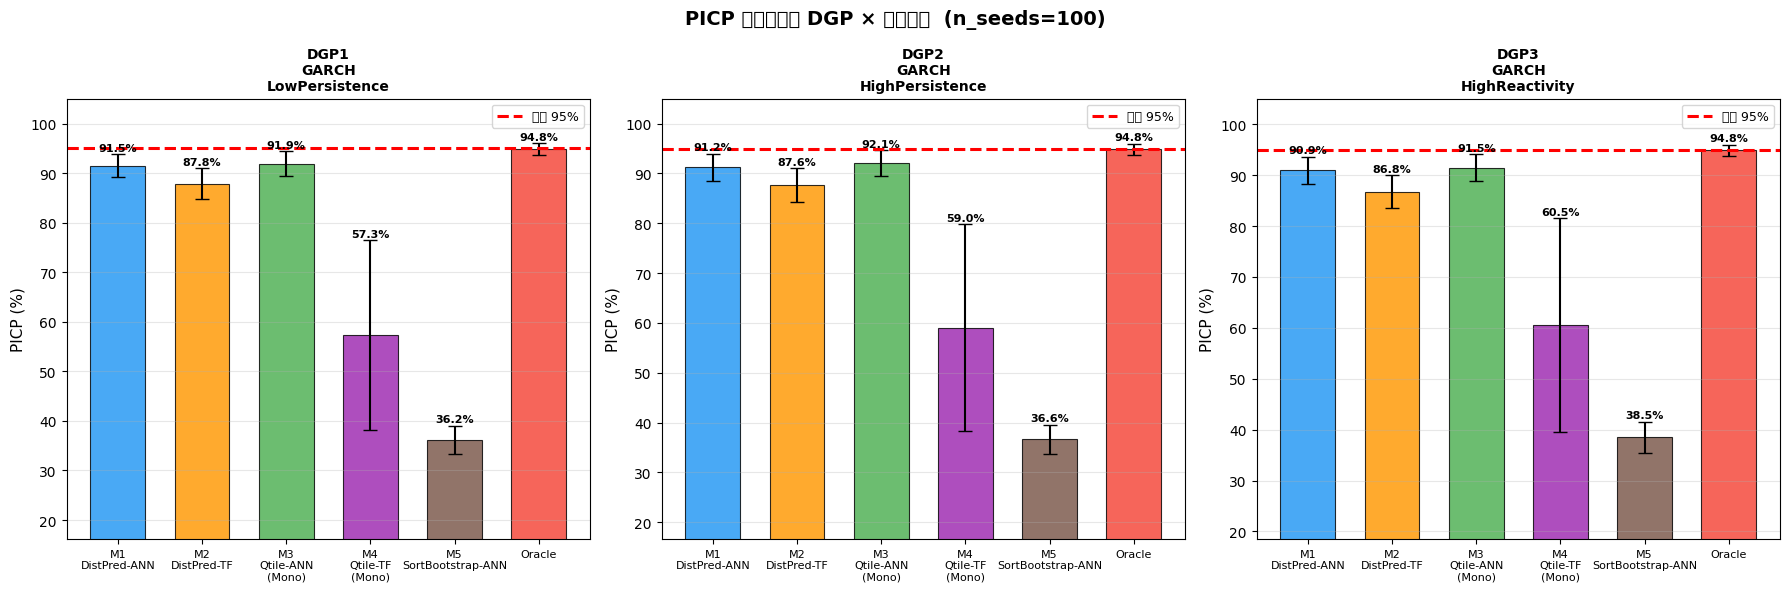

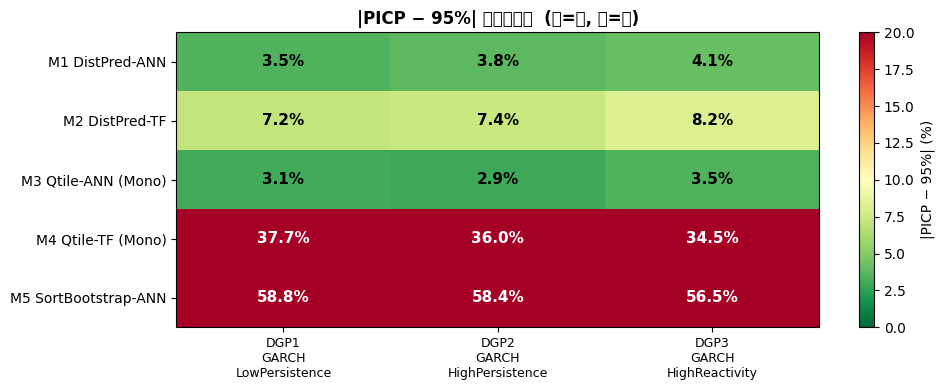

✅ PICP 視覺化完成！


In [18]:
non_oracle = [m for m in methods if 'Oracle' not in m]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle(f'PICP 比較：三種 DGP × 五種方法  (n_seeds={cfg.n_seeds})',
             fontsize=14, fontweight='bold')

for ax, dgp in zip(axes, dgp_names):
    x     = np.arange(len(methods))
    width = 0.65
    picp_means, picp_stds, colors_bar = [], [], []

    for method in methods:
        sub = df_all[(df_all['DGP'] == dgp) &
                     (df_all['Method'] == method) &
                     (df_all['Metric'] == 'PICP')]
        picp_means.append(sub['Mean'].values[0] if not sub.empty else 0)
        picp_stds.append(sub['Std'].values[0]   if not sub.empty else 0)
        colors_bar.append(METHOD_COLORS.get(method, 'gray'))

    bars = ax.bar(x, picp_means, width, yerr=picp_stds, capsize=5,
                  color=colors_bar, alpha=0.82, edgecolor='black', linewidth=0.8)
    ax.axhline(95, color='red', linestyle='--', linewidth=2.2, label='目標 95%')

    for bar, m, s in zip(bars, picp_means, picp_stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + 0.3,
                f'{m:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_SHORT.get(m, m).replace(' ', '\n') for m in methods], fontsize=8)
    ax.set_ylabel('PICP (%)', fontsize=11)
    ax.set_title(dgp.replace('_', '\n'), fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9)
    ax.set_ylim(max(0, min(picp_means) - 20), min(105, max(picp_means) + 15))

plt.tight_layout()
if cfg.save_plots:
    plt.savefig(f'{cfg.output_dir}/picp_three_dgps.png', dpi=200, bbox_inches='tight')
plt.show()

# 偏差熱力圖
deviation_matrix = np.zeros((len(non_oracle), len(dgp_names)))
for j, dgp in enumerate(dgp_names):
    for i, method in enumerate(non_oracle):
        sub = df_all[(df_all['DGP'] == dgp) &
                     (df_all['Method'] == method) &
                     (df_all['Metric'] == 'PICP')]
        if not sub.empty:
            deviation_matrix[i, j] = abs(sub['Mean'].values[0] - 95)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(deviation_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=20)
ax.set_xticks(range(len(dgp_names)))
ax.set_xticklabels([d.replace('_', '\n') for d in dgp_names], fontsize=9)
ax.set_yticks(range(len(non_oracle)))
ax.set_yticklabels([METHOD_SHORT.get(m, m) for m in non_oracle], fontsize=10)
ax.set_title('|PICP − 95%| 偏差熱力圖  (綠=好, 紅=差)', fontsize=12, fontweight='bold')

for i in range(len(non_oracle)):
    for j in range(len(dgp_names)):
        ax.text(j, i, f'{deviation_matrix[i,j]:.1f}%',
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if deviation_matrix[i, j] > 12 else 'black')

plt.colorbar(im, ax=ax, label='|PICP − 95%| (%)')
plt.tight_layout()
if cfg.save_plots:
    plt.savefig(f'{cfg.output_dir}/picp_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ PICP 視覺化完成！")

## 17. 最終結論

In [19]:
print("\n" + "=" * 70)
print("🎯 最終結論")
print("=" * 70)
print(f"重複 {cfg.n_seeds} 個 seed，跨三種 DGP 的綜合表現（五種方法）：\n")

print(f"  {'方法':<40}  {'平均|PICP-95%|':>14}  {'最差 DGP'}")
print(f"  {'─'*40}  {'─'*14}  {'─'*30}")
for method in non_oracle:
    deviations = {}
    for dgp in dgp_names:
        sub = df_all[(df_all['DGP'] == dgp) &
                     (df_all['Method'] == method) &
                     (df_all['Metric'] == 'PICP')]
        if not sub.empty:
            deviations[dgp] = abs(sub['Mean'].values[0] - 95)
    if deviations:
        avg_dev   = np.mean(list(deviations.values()))
        worst_dgp = max(deviations, key=deviations.get)
        print(f"  {method:<40}  {avg_dev:>12.2f}%  {worst_dgp} ({deviations[worst_dgp]:.2f}%)")

best_overall = min(non_oracle, key=lambda m: np.mean([
    abs(df_all[(df_all['DGP'] == dgp) & (df_all['Method'] == m) &
               (df_all['Metric'] == 'PICP')]['Mean'].values[0] - 95)
    for dgp in dgp_names
    if not df_all[(df_all['DGP'] == dgp) & (df_all['Method'] == m) &
                  (df_all['Metric'] == 'PICP')].empty
]))
print(f"\n  🏆 綜合最佳方法（最接近 95% PICP）: {best_overall}")

# 逐位置涵蓋率補充分析
print(f"\n{'─'*70}")
print(f"📍 逐位置涵蓋率補充分析（position-wise coverage）：")
print(f"   測試集 {N_TEST} 個位置，各方法每個位置累積 {cfg.n_seeds} 次結果\n")
print(f"  {'方法':<40}  {'DGP':<30}  {'位置涵蓋率均值':>14}  {'低於90%的位置':>14}")
print(f"  {'─'*40}  {'─'*30}  {'─'*14}  {'─'*14}")
for dgp in dgp_names:
    for method in non_oracle:
        cov      = covered_matrices[dgp][method].mean(axis=0) * 100
        below_90 = np.mean(cov < 90) * 100
        print(f"  {method:<40}  {dgp:<30}  {cov.mean():>13.2f}%  {below_90:>12.1f}%")

print("\n" + "=" * 70)
print(f"📁 所有結果已儲存至: {cfg.output_dir}/")
print("   ├── all_results.csv            (純量指標，各方法×DGP 的 mean±std)")
print("   ├── position_coverage.csv      (逐位置涵蓋率)")
print("   ├── pos_coverage_*.png         (逐位置涵蓋率折線圖)")
print("   ├── pos_coverage_hist_all.png  (涵蓋率分布直方圖)")
print("   ├── picp_three_dgps.png        (整體 PICP 長條圖)")
print("   └── picp_heatmap.png           (偏差熱力圖)")
print("=" * 70)


🎯 最終結論
重複 100 個 seed，跨三種 DGP 的綜合表現（五種方法）：

  方法                                          平均|PICP-95%|  最差 DGP
  ────────────────────────────────────────  ──────────────  ──────────────────────────────
  M1_DistPred_ANN                                   3.78%  DGP3_GARCH_HighReactivity (4.07%)
  M2_DistPred_Minusformer                           7.59%  DGP3_GARCH_HighReactivity (8.24%)
  M3_QuantileANN_Monotone                           3.19%  DGP3_GARCH_HighReactivity (3.51%)
  M4_QuantileMinusformer_Monotone                  36.06%  DGP1_GARCH_LowPersistence (37.72%)
  M5_SortBootstrap_ANN                             57.91%  DGP1_GARCH_LowPersistence (58.85%)

  🏆 綜合最佳方法（最接近 95% PICP）: M3_QuantileANN_Monotone

──────────────────────────────────────────────────────────────────────
📍 逐位置涵蓋率補充分析（position-wise coverage）：
   測試集 240 個位置，各方法每個位置累積 100 次結果

  方法                                        DGP                                    位置涵蓋率均值        低於90%的位置
  ───────────────────────────